# NAS-RL-VRPTW v7: Neural Architecture Search for Vehicle Routing with Time Windows

**CDS526 Case Study — Lingnan University**

## README

### What This Code Does
This notebook implements a Neural Architecture Search (NAS) pipeline that uses an Evolutionary Algorithm (EA) to optimize the architecture of a Deep Q-Network (DQN) for solving the Vehicle Routing Problem with Time Windows (VRPTW). It combines three course topics: NAS (A.10), Evolutionary RL (A.9), and VRPTW (A.3.2).

### How to Run
1. Open in Google Colab with GPU runtime (A100 recommended)
2. Run cells in order: Cell 1 (install) → Cell 2 (mount drive) → Cell 3 (load pipeline) → Cell 4 (run evolution)
3. Cells 5–10 are visualization and analysis — run after Cell 4 completes
4. Cell 11 (Solomon benchmark) is optional — tests generalization on standard benchmark
5. Estimated runtime: ~3h per run × 5 runs = ~16h total on A100

### Key Components
- **SECTION 0**: Configuration dataclass with all hyperparameters
- **SECTION 1**: Checkpoint manager for Colab crash recovery
- **SECTION 2**: VRPTW instance generator (GMM clustered) + Solomon loader
- **SECTION 3**: Gymnasium-compliant VRPTW environment with action masking
- **SECTION 4**: Variable-depth DQN with optional self-attention (NAS search space)
- **SECTION 5**: DQN trainer with epsilon-greedy exploration and masked Q-values
- **SECTION 6**: EA with stochastic ranking, fitness sharing, deterministic crowding, and AOS
- **SECTION 7**: Baselines (NN heuristic, fixed architecture, random architecture search)
- **SECTION 8**: Multi-run experiment wrapper with per-run seeding

### v7 Changes
- **Action masking**: invalid actions (visited, capacity, TW infeasible) get Q = -∞
- **Depot time reset**: returning to depot dispatches a new vehicle with time reset to 0
- **TW feasibility in mask**: `get_action_mask()` checks arrival ≤ tw_latest

## Cell 1: Install Dependencies

In [2]:
!pip install torch torchvision --quiet 2>/dev/null
!pip install gymnasium scipy matplotlib --quiet 2>/dev/null
print("[OK] Dependencies installed.")

[OK] Dependencies installed.


## Cell 2: Mount Google Drive
**Re-run after every reconnection.**

In [3]:
from google.colab import drive
drive.mount("/content/drive")
print("[OK] Google Drive mounted.")

Mounted at /content/drive
[OK] Google Drive mounted.


## Cell 3: Pipeline Definition (v7)
Run this cell once (or after runtime restart) to load all classes.

**v7 changes built into the pipeline (no monkey-patching needed):**
- `VRPTWEnv.get_action_mask()` — returns valid action mask
- `VRPTWEnv.step()` — resets time on depot return, includes mask in info
- `RLTrainer` — masked epsilon-greedy + masked Q-target computation


In [4]:
"""
=============================================================================
NAS-RL-VRPTW v7 — Action Masking + TW Feasibility
=============================================================================
"""

import os, sys, json, time, pickle, random, hashlib, logging, math
import numpy as np
from copy import deepcopy
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple, Optional, Any
from collections import deque

try:
    import gymnasium as gym
    from gymnasium import spaces
    HAS_GYM = True
except ImportError:
    HAS_GYM = False
    print("[WARN] gymnasium not installed.")


# ============================================================================
# SECTION 0: CONFIGURATION
# ============================================================================

@dataclass
class PipelineConfig:
    # --- Paths ---
    drive_root: str = "/content/drive/MyDrive/CDS526_NAS_RL_VRPTW_v7_2"
    checkpoint_dir: str = "checkpoints"
    results_dir: str = "results"
    logs_dir: str = "logs"

    # --- VRPTW Problem ---
    num_customers: int = 20
    vehicle_capacity: int = 50
    num_vehicles: int = 5
    map_size: float = 100.0
    depot_position: Tuple[float, float] = (50.0, 50.0)
    seed_instances: int = 42
    num_train_instances: int = 100
    num_eval_instances: int = 20

    # --- Time Windows ---
    planning_horizon: float = 1000.0
    service_time: float = 10.0
    tw_width_range: Tuple[float, float] = (50.0, 200.0)

    # --- Instance Distribution ---
    distribution_type: str = "clustered"  # 'clustered', 'random', 'mixed'
    num_clusters: int = 3

    # --- Solomon Benchmark ---
    use_solomon: bool = False
    solomon_dir: str = ""
    solomon_instance: str = "C101"

    # --- NAS Search Space ---
    min_layers: int = 2
    max_layers: int = 6
    hidden_dim_choices: List[int] = field(default_factory=lambda: [32, 64, 128, 256])
    activation_choices: List[str] = field(default_factory=lambda: ["relu", "tanh", "elu", "gelu"])
    use_attention_choices: List[bool] = field(default_factory=lambda: [True, False])
    lr_choices: List[float] = field(default_factory=lambda: [1e-4, 3e-4, 5e-4, 1e-3])
    dropout_choices: List[float] = field(default_factory=lambda: [0.0, 0.1, 0.2])

    # --- EA ---
    population_size: int = 20
    num_generations: int = 30
    tournament_size: int = 3
    elite_size: int = 2
    sharing_radius: float = 0.3
    sharing_alpha: float = 1.0
    use_crowding: bool = True
    stochastic_ranking_pf: float = 0.45
    use_adaptive_ops: bool = True
    aos_window: int = 5
    aos_min_prob: float = 0.05

    # --- RL ---
    rl_episodes_per_eval: int = 500
    rl_batch_size: int = 256
    rl_gamma: float = 0.99
    rl_epsilon_start: float = 1.0
    rl_epsilon_end: float = 0.05
    rl_epsilon_decay: int = 400
    rl_target_update: int = 10
    rl_memory_size: int = 10000

    # --- Stats ---
    num_independent_runs: int = 5
    statistical_alpha: float = 0.05

    # --- Checkpointing ---
    checkpoint_every_gen: int = 1
    checkpoint_every_eval: int = 1
    max_checkpoints_kept: int = 9999999999

    # --- Seed ---
    global_seed: int = 42

    def get_checkpoint_path(self):
        return os.path.join(self.drive_root, self.checkpoint_dir)
    def get_results_path(self):
        return os.path.join(self.drive_root, self.results_dir)
    def get_logs_path(self):
        return os.path.join(self.drive_root, self.logs_dir)


def make_logger(name="nas_vrptw", log_file=None):
    """
    Create a logger that ALWAYS prints to console.
    FIX: Does not use logging.basicConfig (broken on cell re-runs).
    """
    logger = logging.getLogger(name)
    logger.handlers.clear()
    logger.setLevel(logging.INFO)
    # Console handler — always works
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter('%(asctime)s [%(levelname)s] %(message)s'))
    logger.addHandler(ch)
    # File handler — if path provided
    if log_file:
        os.makedirs(os.path.dirname(log_file), exist_ok=True)
        fh = logging.FileHandler(log_file)
        fh.setLevel(logging.INFO)
        fh.setFormatter(logging.Formatter('%(asctime)s [%(levelname)s] %(message)s'))
        logger.addHandler(fh)
    return logger


def setup_environment(config):
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        print("[OK] Google Drive mounted.")
    except ImportError:
        print("[INFO] Not on Colab.")
    for path in [config.get_checkpoint_path(), config.get_results_path(), config.get_logs_path()]:
        os.makedirs(path, exist_ok=True)
    log_file = os.path.join(config.get_logs_path(), f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")
    logger = make_logger("nas_vrptw", log_file)
    logger.info("Environment setup complete.")
    return logger


# ============================================================================
# SECTION 1: CHECKPOINT MANAGER
# ============================================================================

class CheckpointManager:
    def __init__(self, config, logger=None):
        self.config = config
        self.checkpoint_dir = config.get_checkpoint_path()
        self.logger = logger or make_logger()

    def save_checkpoint(self, state, tag="gen"):
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gen = state.get("generation", 0)
        eval_idx = state.get("eval_index", -1)
        filename = f"ckpt_{tag}_g{gen:03d}_e{eval_idx:03d}_{timestamp}.pkl"
        filepath = os.path.join(self.checkpoint_dir, filename)
        state["_meta"] = {"timestamp": timestamp, "tag": tag, "generation": gen,
                          "eval_index": eval_idx, "config_hash": self._hash_config()}
        state["_rng"] = {"python": random.getstate(), "numpy": np.random.get_state()}
        try:
            import torch
            state["_rng"]["torch"] = torch.random.get_rng_state()
            if torch.cuda.is_available():
                state["_rng"]["torch_cuda"] = torch.cuda.get_rng_state_all()
        except ImportError:
            pass
        with open(filepath, 'wb') as f:
            pickle.dump(state, f, protocol=pickle.HIGHEST_PROTOCOL)
        self.logger.info(f"[CKPT] {filename}")
        self._cleanup()

    def load_latest_checkpoint(self):
        checkpoints = self._list()
        if not checkpoints:
            return None
        for ckpt_path in reversed(checkpoints):
            try:
                with open(ckpt_path, 'rb') as f:
                    state = pickle.load(f)
                if state.get("_meta", {}).get("config_hash") != self._hash_config():
                    continue
                rng = state.pop("_rng", {})
                if "python" in rng: random.setstate(rng["python"])
                if "numpy" in rng: np.random.set_state(rng["numpy"])
                try:
                    import torch
                    if "torch" in rng: torch.random.set_rng_state(rng["torch"])
                    if "torch_cuda" in rng and torch.cuda.is_available():
                        torch.cuda.set_rng_state_all(rng["torch_cuda"])
                except ImportError:
                    pass
                meta = state.pop("_meta", {})
                self.logger.info(f"[CKPT] Loaded gen={meta.get('generation')}, eval={meta.get('eval_index')}")
                return state
            except Exception as e:
                self.logger.warning(f"[CKPT] Failed {ckpt_path}: {e}")
        return None

    def _list(self):
        if not os.path.exists(self.checkpoint_dir): return []
        return sorted([os.path.join(self.checkpoint_dir, f) for f in os.listdir(self.checkpoint_dir) if f.endswith(".pkl")],
                      key=os.path.getmtime)

    def _cleanup(self):
        ckpts = self._list()
        while len(ckpts) > self.config.max_checkpoints_kept:
            os.remove(ckpts.pop(0))

    def _hash_config(self):
        critical = {"num_customers": self.config.num_customers, "population_size": self.config.population_size,
                     "num_generations": self.config.num_generations, "global_seed": self.config.global_seed,
                     "distribution_type": self.config.distribution_type}
        return hashlib.md5(json.dumps(critical, sort_keys=True).encode()).hexdigest()


# ============================================================================
# SECTION 2: VRPTW INSTANCE + GMM + SOLOMON LOADER
# ============================================================================

class VRPTWInstance:
    """VRPTW instance with GMM distributions and Solomon loader."""

    def __init__(self, num_customers, vehicle_capacity, num_vehicles,
                 map_size, depot, seed=None, distribution='clustered',
                 num_clusters=3, tw_width_range=(50.0, 200.0),
                 service_time=10.0, planning_horizon=1000.0):
        rng = np.random.RandomState(seed)
        self.num_customers = num_customers
        self.vehicle_capacity = vehicle_capacity
        self.num_vehicles = num_vehicles
        self.map_size = map_size
        self.depot = np.array(depot, dtype=np.float64)
        self.service_time_default = service_time
        self.planning_horizon = planning_horizon

        if distribution == 'clustered':
            self.locations = self._generate_gmm(rng, num_customers, map_size,
                                                num_clusters, cluster_std=map_size*0.08)
        elif distribution == 'mixed':
            n_c = num_customers // 2
            n_r = num_customers - n_c
            loc_c = self._generate_gmm(rng, n_c, map_size, num_clusters, cluster_std=map_size*0.1)
            loc_r = rng.uniform(0, map_size, size=(n_r, 2))
            self.locations = np.vstack([loc_c, loc_r])[rng.permutation(num_customers)]
        else:
            self.locations = rng.uniform(0, map_size, size=(num_customers, 2))

        self.locations = np.clip(self.locations, 0, map_size)
        self.demands = rng.randint(1, vehicle_capacity // 3, size=num_customers)

        all_points = np.vstack([self.depot.reshape(1, 2), self.locations]) # Build (n+1)×(n+1) Euclidean distance matrix: index 0=depot, 1..n=customers
        diff = all_points[:, np.newaxis, :] - all_points[np.newaxis, :, :]
        self.distance_matrix = np.sqrt((diff ** 2).sum(axis=2))
        self.travel_time_matrix = self.distance_matrix.copy()
        self.service_times = np.full(num_customers, service_time)

        self.time_windows = np.zeros((num_customers, 2), dtype=np.float64) # Generate time windows: center based on depot distance + random offset, width from tw_width_range
        tw_min_w, tw_max_w = tw_width_range
        for i in range(num_customers):
            dist_dep = self.distance_matrix[0, i + 1]
            center = dist_dep + rng.uniform(0, planning_horizon * 0.6)
            width = rng.uniform(tw_min_w, tw_max_w)
            earliest = max(0.0, center - width / 2)
            latest = min(planning_horizon, center + width / 2)
            if latest < earliest + service_time:
                latest = earliest + service_time + tw_min_w
            self.time_windows[i] = [earliest, min(latest, planning_horizon)]
        self.depot_tw = np.array([0.0, planning_horizon])

    @staticmethod
    def _generate_gmm(rng, n_points, map_size, n_clusters, cluster_std=8.0):
        centers = rng.uniform(map_size * 0.15, map_size * 0.85, size=(n_clusters, 2))
        assignments = rng.choice(n_clusters, size=n_points)
        return np.array([rng.normal(centers[assignments[i]], cluster_std) for i in range(n_points)])

    @classmethod
    def from_solomon(cls, filepath):
        with open(filepath, 'r') as f: # Parse Solomon format: find the 2-integer line (num_vehicles, capacity), then read 7-column customer rows
            lines = [l.strip() for l in f.readlines() if l.strip()]
        vehicle_idx = None
        for i, line in enumerate(lines):
            parts = line.split()
            if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
                vehicle_idx = i; break
        if vehicle_idx is None:
            raise ValueError(f"Could not parse: {filepath}")
        num_vehicles, capacity = int(lines[vehicle_idx].split()[0]), int(lines[vehicle_idx].split()[1])
        customers = []
        for line in lines[vehicle_idx + 1:]:
            parts = line.split()
            if len(parts) >= 7:
                try: customers.append([int(p) for p in parts[:7]])
                except ValueError: continue
        if not customers:
            raise ValueError(f"No data in {filepath}")
        depot = customers[0]; cust = customers[1:] # Row 0 is depot (CUST_NO=0); remaining rows are customers
        inst = cls.__new__(cls)
        inst.num_customers = len(cust)
        inst.vehicle_capacity = capacity
        inst.num_vehicles = num_vehicles
        inst.map_size = 100.0
        inst.depot = np.array([depot[1], depot[2]], dtype=np.float64)
        inst.service_time_default = depot[6]
        inst.planning_horizon = float(depot[5])
        inst.depot_tw = np.array([float(depot[4]), float(depot[5])])
        inst.locations = np.array([[c[1], c[2]] for c in cust], dtype=np.float64)
        inst.demands = np.array([c[3] for c in cust], dtype=np.int32)
        inst.time_windows = np.array([[c[4], c[5]] for c in cust], dtype=np.float64)
        inst.service_times = np.array([c[6] for c in cust], dtype=np.float64)
        all_pts = np.vstack([inst.depot.reshape(1, 2), inst.locations]) # Rebuild Euclidean distance/travel-time matrices for the loaded instance
        diff = all_pts[:, np.newaxis, :] - all_pts[np.newaxis, :, :]
        inst.distance_matrix = np.sqrt((diff ** 2).sum(axis=2))
        inst.travel_time_matrix = inst.distance_matrix.copy()
        return inst


def create_instances(config, seed_offset=0, count=None):
    count = count or config.num_train_instances
    return [VRPTWInstance(
        num_customers=config.num_customers, vehicle_capacity=config.vehicle_capacity,
        num_vehicles=config.num_vehicles, map_size=config.map_size, depot=config.depot_position,
        seed=config.seed_instances + seed_offset + i, distribution=config.distribution_type,
        num_clusters=config.num_clusters, tw_width_range=config.tw_width_range,
        service_time=config.service_time, planning_horizon=config.planning_horizon,
    ) for i in range(count)]


# ============================================================================
# SECTION 3: GYMNASIUM-COMPLIANT VRPTW ENVIRONMENT
# ============================================================================

class VRPTWEnv(gym.Env if HAS_GYM else object):
    """
    Gymnasium-compliant VRPTW environment.

    FIX v5: Invalid actions (revisit, over-capacity) now check truncation.
    Previously they returned truncated=False unconditionally, causing
    infinite episodes when the agent repeatedly picks bad actions.
    """

    metadata = {"render_modes": []}

    def __init__(self, instance, max_steps_factor=4):
        super().__init__()
        self.instance = instance
        n = instance.num_customers
        self.max_steps = n * max_steps_factor
        obs_dim = 4 + 7 * n # Observation: [current_x, current_y, remaining_cap, current_time] + 7 features per customer
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(obs_dim,), dtype=np.float32) if HAS_GYM else None
        self.action_space = spaces.Discrete(n + 1) if HAS_GYM else None
        self._obs_dim = obs_dim
        self._n_actions = n + 1 # Actions: 0=return to depot, 1..n=visit customer i
        self._reset_state()

    def _reset_state(self):
        self.visited = set()
        self.current_node = 0
        self.current_load = 0
        self.current_time = 0.0
        self.total_distance = 0.0
        self.route = [0]
        self.vehicles_used = 1
        self.constraint_violations = 0
        self.tw_violations = 0
        self.capacity_violations = 0
        self.steps_taken = 0

    def reset(self, seed=None, options=None):
        if seed is not None and HAS_GYM:
            super().reset(seed=seed)
        self._reset_state()
        return self._get_observation(), self._get_info()

    def step(self, action):
        self.steps_taken += 1
        inst = self.instance
        prev_node = self.current_node
        reward = 0.0
        terminated = False

        if action == 0:
            # Return to depot → dispatch new vehicle (time resets)
            if self.current_node == 0:
                # Already at depot — penalize wasted action
                self.constraint_violations += 1
                truncated = self.steps_taken >= self.max_steps
                return self._get_observation(), -5.0, False, truncated, self._get_info()
            dist = inst.distance_matrix[prev_node, 0]
            self.total_distance += dist
            # v7 fix: new vehicle dispatched → time resets to 0
            self.current_time = 0.0
            self.current_node = 0
            self.current_load = 0
            self.vehicles_used += 1
            self.route.append(0)
            reward = -dist
        else:
            cust_idx = action - 1

            # FIX: Invalid actions MUST check truncation before returning
            # Check revisit
            if action in self.visited:
                self.constraint_violations += 1
                truncated = self.steps_taken >= self.max_steps
                info = self._get_info()
                info["invalid"] = True
                return self._get_observation(), -10.0, False, truncated, info

            # Check capacity
            demand = inst.demands[cust_idx]
            if self.current_load + demand > inst.vehicle_capacity:
                self.constraint_violations += 1
                self.capacity_violations += 1
                truncated = self.steps_taken >= self.max_steps
                info = self._get_info()
                info["invalid"] = True
                return self._get_observation(), -10.0, False, truncated, info

            # Valid move: travel
            dist = inst.distance_matrix[prev_node, action]
            self.total_distance += dist
            self.current_time += inst.travel_time_matrix[prev_node, action]

            # Time window
            tw_earliest, tw_latest = inst.time_windows[cust_idx]
            if self.current_time < tw_earliest:
                self.current_time = tw_earliest  # Wait
            if self.current_time > tw_latest:
                self.constraint_violations += 1
                self.tw_violations += 1
                reward -= 5.0

            self.current_time += inst.service_times[cust_idx]
            self.current_load += demand
            self.visited.add(action)
            self.current_node = action
            self.route.append(action)
            reward += -dist

        # Termination check
        if len(self.visited) == inst.num_customers:
            if self.current_node != 0:
                self.total_distance += inst.distance_matrix[self.current_node, 0]
                self.current_time += inst.travel_time_matrix[self.current_node, 0]
                self.route.append(0)
            terminated = True
            # Completion bonus: reward for actually serving all customers
            reward += 50.0

        truncated = self.steps_taken >= self.max_steps and not terminated
        if truncated:
            # Penalty for failing to complete: -10 per unserved customer
            unserved = inst.num_customers - len(self.visited)
            reward -= unserved * 10.0
        return self._get_observation(), reward, terminated, truncated, self._get_info()

    def _get_observation(self):
        inst = self.instance
        n = inst.num_customers
        obs = np.zeros(self._obs_dim, dtype=np.float32)  # Encode state: first 4 dims = agent pos (normalized), remaining capacity, time fraction
                                   # Per-customer (7 dims each): position, demand ratio, visited flag, capacity-feasible flag, TW bounds
        if self.current_node == 0:
            obs[0:2] = inst.depot / inst.map_size
        else:
            obs[0:2] = inst.locations[self.current_node - 1] / inst.map_size
        obs[2] = (inst.vehicle_capacity - self.current_load) / inst.vehicle_capacity
        obs[3] = min(self.current_time / inst.planning_horizon, 1.0)
        for i in range(n):
            b = 4 + i * 7
            obs[b:b+2] = inst.locations[i] / inst.map_size
            obs[b+2] = inst.demands[i] / inst.vehicle_capacity
            obs[b+3] = 1.0 if (i + 1) in self.visited else 0.0
            obs[b+4] = 1.0 if (self.current_load + inst.demands[i] <= inst.vehicle_capacity) else 0.0
            obs[b+5] = inst.time_windows[i, 0] / inst.planning_horizon
            obs[b+6] = inst.time_windows[i, 1] / inst.planning_horizon
        return obs

    def get_action_mask(self):
        """
        Returns boolean mask of shape (n_actions,). mask[a]=True means action a is VALID.
        Checks: not visited, capacity feasible, TW feasible (arrival <= tw_latest).
        """
        inst = self.instance
        n = inst.num_customers
        mask = np.zeros(n + 1, dtype=bool)
        # Action 0: return to depot (valid if not already at depot, or all served)
        if self.current_node != 0 or len(self.visited) == n:
            mask[0] = True
        # Actions 1..n: visit customer
        for i in range(n):
            action = i + 1
            if action in self.visited:
                continue
            if self.current_load + inst.demands[i] > inst.vehicle_capacity:
                continue
            # TW feasibility: can we arrive before deadline?
            arrival_time = self.current_time + inst.travel_time_matrix[self.current_node, action]
            if arrival_time > inst.time_windows[i, 1]:
                continue
            mask[action] = True
        # Safety: if nothing valid, allow depot return
        if not mask.any():
            mask[0] = True
        return mask

    def _get_info(self):
        info = {"total_distance": self.total_distance, "vehicles_used": self.vehicles_used,
                "customers_served": len(self.visited), "constraint_violations": self.constraint_violations,
                "tw_violations": self.tw_violations, "capacity_violations": self.capacity_violations,
                "current_time": self.current_time}
        info["action_mask"] = self.get_action_mask()
        return info

    @property
    def observation_size(self): return self._obs_dim
    @property
    def action_size(self): return self._n_actions


# ============================================================================
# SECTION 4: ARCHITECTURE + NETWORK
# ============================================================================

@dataclass
class Architecture:
    num_layers: int = 3
    hidden_dims: List[int] = field(default_factory=lambda: [128, 128, 128])
    activation: str = "relu"
    use_attention: bool = False
    learning_rate: float = 3e-4
    dropout_rate: float = 0.0
    fitness: float = float('inf')
    fitness_std: float = 0.0
    constraint_violation: float = 0.0
    eval_time: float = 0.0
    param_count: int = 0
    is_evaluated: bool = False

    def to_dict(self): return asdict(self)

    @classmethod
    def from_dict(cls, d):
        af = {'num_layers','hidden_dims','activation','use_attention','learning_rate','dropout_rate'}
        obj = cls(**{k: v for k, v in d.items() if k in af})
        for f in ['fitness','fitness_std','constraint_violation','eval_time','param_count','is_evaluated']:
            if f in d: setattr(obj, f, d[f])
        return obj

    def __repr__(self):
        return (f"Arch(L={self.num_layers}, D={self.hidden_dims}, "
                f"act={self.activation}, attn={self.use_attention}, "
                f"lr={self.learning_rate:.1e}, fit={self.fitness:.2f})")


def build_network(arch, obs_size, action_size):
    import torch; import torch.nn as nn
    act_map = {"relu": nn.ReLU, "tanh": nn.Tanh, "elu": nn.ELU, "gelu": nn.GELU}
    act_fn = act_map.get(arch.activation, nn.ReLU)

    class Net(nn.Module): # Build DQN: first hidden layer → optional self-attention → remaining hidden layers → Q-value output
        def __init__(self):
            super().__init__()
            self.use_attn = arch.use_attention
            self.pre = nn.ModuleList(); self.post = nn.ModuleList(); self.attn = None
            in_d = obs_size
            for i in range(arch.num_layers):
                out_d = arch.hidden_dims[i] if i < len(arch.hidden_dims) else arch.hidden_dims[-1]
                blk = nn.Sequential(nn.Linear(in_d, out_d), act_fn())
                if arch.dropout_rate > 0: blk.append(nn.Dropout(arch.dropout_rate))
                if i == 0:
                    self.pre.append(blk)
                    if self.use_attn:
                        self.attn = nn.MultiheadAttention(embed_dim=out_d, num_heads=1, batch_first=True)
                        self.attn_norm = nn.LayerNorm(out_d)
                else:
                    self.post.append(blk)
                in_d = out_d
            self.out = nn.Linear(in_d, action_size)

        def forward(self, x):
            for l in self.pre: x = l(x)
            if self.use_attn and self.attn is not None:
                xq = x.unsqueeze(1) # Self-attention: treat hidden state as single-token sequence for global context
                ao, _ = self.attn(xq, xq, xq)
                x = self.attn_norm(x + ao.squeeze(1))
            for l in self.post: x = l(x)
            return self.out(x)

    m = Net()
    arch.param_count = sum(p.numel() for p in m.parameters())
    return m


# ============================================================================
# SECTION 5: RL TRAINER
# ============================================================================

class RLTrainer:
    """v7: DQN with action masking — invalid actions get Q = -inf."""
    def __init__(self, arch, config, train_instances, eval_instances):
        import torch
        self.arch = arch; self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Initialize policy and target networks (Double DQN pattern) with experience replay buffer
        sample_env = VRPTWEnv(train_instances[0])
        self.obs_size = sample_env.observation_size
        self.action_size = sample_env.action_size
        self.policy_net = build_network(arch, self.obs_size, self.action_size).to(self.device)
        self.target_net = build_network(arch, self.obs_size, self.action_size).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=arch.learning_rate)
        self.memory = deque(maxlen=config.rl_memory_size)
        self.train_instances = train_instances
        self.eval_instances = eval_instances

    def train(self):
        import torch
        cfg = self.config; rewards_log = []
        for ep in range(cfg.rl_episodes_per_eval):
            inst = random.choice(self.train_instances)
            env = VRPTWEnv(inst)
            obs, info = env.reset()
            mask = info["action_mask"]
            total_r = 0.0
            eps = cfg.rl_epsilon_end + (cfg.rl_epsilon_start - cfg.rl_epsilon_end) * \  # Exponential epsilon decay: starts at 1.0 (fully random), decays to 0.05 (mostly greedy)
                  np.exp(-ep / cfg.rl_epsilon_decay)
            while True:
                if random.random() < eps:
                    # Masked random: only pick from valid actions
                    valid_actions = np.where(mask)[0]
                    a = int(np.random.choice(valid_actions))
                else:
                    # Masked greedy: Q(invalid) = -inf
                    with torch.no_grad():
                        q = self.policy_net(
                            torch.FloatTensor(obs).unsqueeze(0).to(self.device)
                        ).squeeze(0).cpu().numpy()
                        q[~mask] = -np.inf
                        a = int(np.argmax(q))
                nobs, r, term, trunc, info = env.step(a)
                next_mask = info["action_mask"]
                done = term or trunc
                self.memory.append((obs, a, r, nobs, done, next_mask)) # Store transition with next-state action mask for masked target Q computation
                if len(self.memory) >= cfg.rl_batch_size:
                    self._train_step()
                total_r += r; obs = nobs; mask = next_mask
                if done: break
            rewards_log.append(total_r)
            if ep % cfg.rl_target_update == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())
        d, v = self._evaluate()
        return {"mean_distance": np.mean(d), "std_distance": np.std(d),
                "mean_violations": np.mean(v), "train_rewards": rewards_log,
                "eval_distances": d}

    def _train_step(self):
        import torch
        batch = random.sample(self.memory, self.config.rl_batch_size) # Sample mini-batch from replay buffer, compute masked TD target, update policy via MSE loss
        s, a, r, ns, dn, nm = zip(*batch)
        s = torch.FloatTensor(np.array(s)).to(self.device)
        a = torch.LongTensor(a).unsqueeze(1).to(self.device)
        r = torch.FloatTensor(r).unsqueeze(1).to(self.device)
        ns = torch.FloatTensor(np.array(ns)).to(self.device)
        dn = torch.FloatTensor(dn).unsqueeze(1).to(self.device)
        nm = torch.BoolTensor(np.array(nm)).to(self.device)
        q = self.policy_net(s).gather(1, a)
        with torch.no_grad():
            next_q = self.target_net(ns)
            next_q[~nm] = -1e9  # mask invalid next actions
                        # Mask invalid next-actions with large negative value before taking max Q
            max_next_q = next_q.max(1, keepdim=True)[0]
            tq = r + self.config.rl_gamma * max_next_q * (1 - dn)
        loss = torch.nn.functional.mse_loss(q, tq)
        self.optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

    def _evaluate(self):
        import torch
        dists, viols = [], []
        for inst in self.eval_instances: # Greedy evaluation: run trained policy on eval instances, penalize unserved customers
            env = VRPTWEnv(inst)
            obs, info = env.reset()
            mask = info["action_mask"]; done = False
            while not done:
                with torch.no_grad():
                    q = self.policy_net(
                        torch.FloatTensor(obs).unsqueeze(0).to(self.device)
                    ).squeeze(0).cpu().numpy()
                    q[~mask] = -np.inf
                    a = int(np.argmax(q))
                obs, _, term, trunc, info = env.step(a)
                mask = info["action_mask"]
                done = term or trunc
            served = info["customers_served"]
            total = inst.num_customers
            dist = info["total_distance"]
            if served < total: # If not all customers served (truncated episode), add distance penalty for unserved
                avg_dist = inst.distance_matrix.mean()
                dist += (total - served) * avg_dist * 2.0
            dists.append(dist)
            viols.append(info["constraint_violations"])
        return dists, viols


# ============================================================================
# SECTION 6: EVOLUTIONARY ALGORITHM
# ============================================================================

class EvolutionaryNAS:
    @staticmethod
    def arch_distance(a1, a2):
        d = abs(a1.num_layers - a2.num_layers) / 4.0 # Normalized distance across 6 dims: layers, hidden dims, activation, attention, lr, dropout
        ml = max(len(a1.hidden_dims), len(a2.hidden_dims))
        dd = sum(abs((a1.hidden_dims[i] if i < len(a1.hidden_dims) else a1.hidden_dims[-1]) -
                     (a2.hidden_dims[i] if i < len(a2.hidden_dims) else a2.hidden_dims[-1])) / 256.0
                 for i in range(ml)) / max(ml, 1)
        d += dd
        d += (0.0 if a1.activation == a2.activation else 1.0)
        d += (0.0 if a1.use_attention == a2.use_attention else 1.0)
        d += abs(math.log10(a1.learning_rate) - math.log10(a2.learning_rate))
        d += abs(a1.dropout_rate - a2.dropout_rate) / 0.2
        return d / 6.0

    @staticmethod
    def sharing_function(dist, sigma, alpha):
        return 1.0 - (dist / sigma) ** alpha if dist < sigma else 0.0

    def compute_shared_fitness(self, pop):
        n = len(pop); shared = [] # Fitness sharing: inflate fitness by niche count to maintain population diversity
        for i in range(n):
            nc = sum(self.sharing_function(self.arch_distance(pop[i], pop[j]),
                     self.config.sharing_radius, self.config.sharing_alpha) for j in range(n))
            shared.append(pop[i].fitness * max(nc, 1.0))
        return shared

    def _tournament_select_shared(self, pop, sf):
        idx = random.sample(range(len(pop)), self.config.tournament_size)
        return pop[min(idx, key=lambda i: sf[i])]

    def deterministic_crowding_replace(self, cur, offspring):
        p = [deepcopy(x) for x in cur] # Deterministic crowding: each offspring replaces its nearest parent if fitter (niching)
        for c in offspring:
            if not c.is_evaluated or c.fitness == float('inf'): continue
            best_i = min(range(len(p)), key=lambda i: self.arch_distance(c, p[i]))
            if c.fitness < p[best_i].fitness: p[best_i] = deepcopy(c)
        return p

    def stochastic_ranking_sort(self, pop):
        p = list(pop); n = len(p); pf = self.config.stochastic_ranking_pf # Stochastic ranking (Runarsson & Yao): bubble sort by fitness with prob pf,
                                              # otherwise by constraint violation — balances feasibility vs objective
        for i in range(n):
            sw = False
            for j in range(n - 1):
                a, b = p[j], p[j+1]
                if (a.constraint_violation == 0 and b.constraint_violation == 0) or random.random() < pf:
                    if b.fitness < a.fitness: p[j], p[j+1] = p[j+1], p[j]; sw = True
                else:
                    if b.constraint_violation < a.constraint_violation: p[j], p[j+1] = p[j+1], p[j]; sw = True
            if not sw: break
        return p

    def __init__(self, config, logger=None):
        self.config = config
        self.logger = logger or make_logger()
        self.ckpt_manager = CheckpointManager(config, self.logger)
        self.fitness_cache = {}; self.hall_of_fame = []
        self.operators = ["xover_uniform", "xover_1pt", "mut_std", "mut_strong"]
        self.op_probs = {o: 0.25 for o in self.operators}
        self.op_rewards = {o: deque(maxlen=config.aos_window) for o in self.operators}
        self.train_instances = create_instances(config, 0, config.num_train_instances)
        self.eval_instances = create_instances(config, 10000, config.num_eval_instances)
        self.logger.info(f"Generated {len(self.train_instances)} train + {len(self.eval_instances)} eval instances ({config.distribution_type})")

    def _update_ops(self):
        if not self.config.use_adaptive_ops: return # AOS: update operator probabilities proportional to recent reward, with minimum floor
        avg = {o: (np.mean(self.op_rewards[o]) if self.op_rewards[o] else 0.0) for o in self.operators}
        tot = sum(max(v, 0) for v in avg.values())
        if tot > 0:
            self.op_probs = {o: max(max(avg[o], 0) / tot, self.config.aos_min_prob) for o in self.operators}
            s = sum(self.op_probs.values())
            self.op_probs = {k: v/s for k, v in self.op_probs.items()}

    def _pick_op(self):
        ops = list(self.op_probs.keys())
        return np.random.choice(ops, p=[self.op_probs[o] for o in ops])

    @staticmethod
    def _fp(a):
        return hashlib.md5(str((a.num_layers, tuple(a.hidden_dims), a.activation,
                                a.use_attention, a.learning_rate, a.dropout_rate)).encode()).hexdigest()

    def _init_pop(self):
        pop = []
        for _ in range(self.config.population_size):
            nl = random.randint(self.config.min_layers, self.config.max_layers)
            pop.append(Architecture(
                num_layers=nl, hidden_dims=[random.choice(self.config.hidden_dim_choices) for _ in range(nl)],
                activation=random.choice(self.config.activation_choices),
                use_attention=random.choice(self.config.use_attention_choices),
                learning_rate=random.choice(self.config.lr_choices),
                dropout_rate=random.choice(self.config.dropout_choices)))
        return pop

    def _xover_uniform(self, p1, p2):
        c = Architecture(num_layers=random.choice([p1.num_layers, p2.num_layers]),
                         activation=random.choice([p1.activation, p2.activation]),
                         use_attention=random.choice([p1.use_attention, p2.use_attention]),
                         learning_rate=random.choice([p1.learning_rate, p2.learning_rate]),
                         dropout_rate=random.choice([p1.dropout_rate, p2.dropout_rate]))
        c.hidden_dims = [random.choice([p1.hidden_dims[i] if i < len(p1.hidden_dims) else p1.hidden_dims[-1],
                                        p2.hidden_dims[i] if i < len(p2.hidden_dims) else p2.hidden_dims[-1]])
                         for i in range(c.num_layers)]
        return c

    def _xover_1pt(self, p1, p2):
        c = Architecture(num_layers=p1.num_layers, activation=p1.activation,
                         use_attention=p2.use_attention, learning_rate=p2.learning_rate,
                         dropout_rate=random.choice([p1.dropout_rate, p2.dropout_rate]))
        mid = c.num_layers // 2
        c.hidden_dims = [(p1 if i < mid else p2).hidden_dims[i]
                         if i < len((p1 if i < mid else p2).hidden_dims)
                         else (p1 if i < mid else p2).hidden_dims[-1]
                         for i in range(c.num_layers)]
        return c

    def _mut_std(self, a):
        c = deepcopy(a); c.is_evaluated = False; c.fitness = float('inf'); c.constraint_violation = 0.0 # Standard mutation: each gene independently perturbed with ~20-30% probability
        if random.random() < 0.3:
            c.num_layers = random.randint(self.config.min_layers, self.config.max_layers)
            while len(c.hidden_dims) < c.num_layers: c.hidden_dims.append(random.choice(self.config.hidden_dim_choices))
            c.hidden_dims = c.hidden_dims[:c.num_layers]
        for i in range(len(c.hidden_dims)):
            if random.random() < 0.3: c.hidden_dims[i] = random.choice(self.config.hidden_dim_choices)
        if random.random() < 0.2: c.activation = random.choice(self.config.activation_choices)
        if random.random() < 0.2: c.use_attention = not c.use_attention
        if random.random() < 0.2: c.learning_rate = random.choice(self.config.lr_choices)
        if random.random() < 0.2: c.dropout_rate = random.choice(self.config.dropout_choices)
        return c

    def _mut_strong(self, a):
        c = deepcopy(a); c.is_evaluated = False; c.fitness = float('inf'); c.constraint_violation = 0.0 # Strong mutation: randomly select 2-4 genes to fully randomize (macro-mutation for diversity)
        gs = random.sample(["L","D","A","T","R","P"], k=random.randint(2, 4))
        if "L" in gs:
            c.num_layers = random.randint(self.config.min_layers, self.config.max_layers)
            c.hidden_dims = [random.choice(self.config.hidden_dim_choices) for _ in range(c.num_layers)]
        if "D" in gs: c.hidden_dims = [random.choice(self.config.hidden_dim_choices) for _ in range(c.num_layers)]
        if "A" in gs: c.activation = random.choice(self.config.activation_choices)
        if "T" in gs: c.use_attention = not c.use_attention
        if "R" in gs: c.learning_rate = random.choice(self.config.lr_choices)
        if "P" in gs: c.dropout_rate = random.choice(self.config.dropout_choices)
        return c

    def _apply_op(self, op, pop, sf):
        p1 = self._tournament_select_shared(pop, sf)
        p2 = self._tournament_select_shared(pop, sf)
        if op == "xover_uniform": return self._xover_uniform(p1, p2)
        elif op == "xover_1pt": return self._xover_1pt(p1, p2)
        elif op == "mut_std": return self._mut_std(p1)
        elif op == "mut_strong": return self._mut_strong(p1)
        return self._xover_uniform(p1, p2)

    def _update_hof(self, a, max_sz=10):
        fp = self._fp(a)
        for i, e in enumerate(self.hall_of_fame):
            if e.get("_fp") == fp:
                if a.fitness < e["fitness"]:
                    self.hall_of_fame[i] = {**a.to_dict(), "_fp": fp}
                    self.hall_of_fame.sort(key=lambda x: x["fitness"])
                return
        self.hall_of_fame.append({**a.to_dict(), "_fp": fp})
        self.hall_of_fame.sort(key=lambda x: x["fitness"])
        if len(self.hall_of_fame) > max_sz: self.hall_of_fame = self.hall_of_fame[:max_sz]

    def _diversity(self, pop):
        return len(set(self._fp(p) for p in pop)) / len(pop)

    # === Eval helper: train one arch, return results, print progress ===
    def _eval_arch(self, arch, label=""):
        fp = self._fp(arch)
        if fp in self.fitness_cache:
            c = self.fitness_cache[fp]
            arch.fitness = c["fitness"]; arch.fitness_std = c["fitness_std"]
            arch.constraint_violation = c.get("constraint_violation", 0)
            arch.param_count = c["param_count"]; arch.is_evaluated = True
            print(f"  [CACHE] {label} fit={arch.fitness:.2f}")
            return
        print(f"  Eval {label}: {arch}")
        t0 = time.time()
        try:
            trainer = RLTrainer(arch, self.config, self.train_instances, self.eval_instances)
            res = trainer.train()
            arch.fitness = res["mean_distance"]; arch.fitness_std = res["std_distance"]
            arch.constraint_violation = res["mean_violations"]; arch.eval_time = time.time() - t0
            arch.is_evaluated = True
            self.fitness_cache[fp] = {"fitness": arch.fitness, "fitness_std": arch.fitness_std,
                                       "constraint_violation": arch.constraint_violation, "param_count": arch.param_count}
            print(f"    -> fit={arch.fitness:.2f} cv={arch.constraint_violation:.1f} ({arch.eval_time:.0f}s)")
        except Exception as e:
            print(f"    -> FAILED: {e}")
            arch.fitness = float('inf'); arch.constraint_violation = 100; arch.is_evaluated = True
        try:
            import torch; del trainer; torch.cuda.empty_cache()
        except: pass

    # ================================================================
    # MAIN LOOP
    # ================================================================

    def run(self):
        state = self.ckpt_manager.load_latest_checkpoint()
        if state:
            generation = state["generation"]
            population = [Architecture.from_dict(d) for d in state["population"]]
            best_ever = Architecture.from_dict(state["best_ever"])
            history = state["history"]
            eval_index = state.get("eval_index", 0)
            gen_phase = state.get("gen_phase", "evaluate")
            self.fitness_cache = state.get("fitness_cache", {})
            self.hall_of_fame = state.get("hall_of_fame", [])
            self.op_probs = state.get("op_probs", self.op_probs)
            pend_off = [Architecture.from_dict(d) for d in state.get("pending_offspring", [])]
            pend_ops = state.get("pending_ops", [])
            pend_eli = [Architecture.from_dict(d) for d in state.get("pending_elites", [])]
            print(f"=== RESUMED gen={generation}, phase={gen_phase}, eval={eval_index} ===")
        else:
            generation = 0; population = self._init_pop()
            best_ever = deepcopy(population[0]); best_ever.fitness = float('inf')
            history = []; eval_index = 0; gen_phase = "evaluate"
            pend_off = []; pend_ops = []; pend_eli = []
            print(f"=== FRESH START pop={len(population)} ===")

        while generation < self.config.num_generations:
            gt = time.time()
            print(f"\n{'='*50} GEN {generation}/{self.config.num_generations} [{gen_phase}] {'='*10}")

            # === PHASE 1: EVALUATE ===
            if gen_phase == "evaluate":
                for i in range(eval_index, len(population)):
                    if population[i].is_evaluated: continue
                    self._eval_arch(population[i], f"{i}/{len(population)}")
                    if population[i].fitness < best_ever.fitness:
                        best_ever = deepcopy(population[i])
                        print(f"    *** NEW BEST: {best_ever.fitness:.2f} ***")
                    self._update_hof(population[i])
                    if (i + 1) % self.config.checkpoint_every_eval == 0:
                        self._save(generation, population, best_ever, history, i+1, "evaluate", "intra", pend_off, pend_ops, pend_eli)
                gen_phase = "evolve"; eval_index = 0

            # === PHASE 2: EVOLVE ===
            if gen_phase == "evolve":
                population = self.stochastic_ranking_sort(population)
                sf = self.compute_shared_fitness(population)
                self._update_ops()
                vf = [p.fitness for p in population if p.fitness < float('inf')]
                stats = {"generation": generation, "best_fitness": population[0].fitness,
                         "mean_fitness": np.mean(vf) if vf else float('inf'),
                         "best_ever": best_ever.fitness,
                         "population_diversity": self._diversity(population),
                         "mean_shared_fitness": float(np.mean(sf)),
                         "mean_constraint_violation": float(np.mean([p.constraint_violation for p in population])),
                         "operator_probs": dict(self.op_probs), "time": time.time() - gt}
                history.append(stats)
                print(f"  best={stats['best_fitness']:.1f} mean={stats['mean_fitness']:.1f} "
                      f"ever={best_ever.fitness:.1f} div={stats['population_diversity']:.2f}")

                if generation < self.config.num_generations - 1:
                    eli = [deepcopy(population[i]) for i in range(self.config.elite_size)] # Preserve top-k elites, generate remaining offspring via AOS-selected operators
                    off = []; ops = []
                    for _ in range(self.config.population_size - self.config.elite_size):
                        o = self._pick_op(); off.append(self._apply_op(o, population, sf)); ops.append(o)
                    pend_off = off; pend_ops = ops; pend_eli = eli

                generation += 1; gen_phase = "evaluate_then_crowd"; eval_index = 0
                if generation % self.config.checkpoint_every_gen == 0:
                    self._save(generation, population, best_ever, history, 0, "evaluate_then_crowd", "gen", pend_off, pend_ops, pend_eli)

            # === PHASE 3: EVALUATE OFFSPRING + CROWD ===
            if gen_phase == "evaluate_then_crowd":
                for i in range(eval_index, len(pend_off)):
                    child = pend_off[i]
                    if child.is_evaluated: continue
                    self._eval_arch(child, f"offspring {i}/{len(pend_off)}")
                    if i < len(pend_ops):
                        self.op_rewards[pend_ops[i]].append(max(best_ever.fitness - child.fitness, 0))
                    if child.fitness < best_ever.fitness:
                        best_ever = deepcopy(child)
                        print(f"    *** NEW BEST: {best_ever.fitness:.2f} ***")
                    self._update_hof(child)
                    if (i + 1) % self.config.checkpoint_every_eval == 0:
                        self._save(generation, population, best_ever, history, i+1, "evaluate_then_crowd", "intra", pend_off, pend_ops, pend_eli)

                if self.config.use_crowding and pend_off: # Deterministic crowding: offspring replace nearest similar parent if better
                                       # Then re-insert elites into first positions if they remain superior
                    evald = [c for c in pend_off if c.is_evaluated]
                    print(f"  Crowding: {len(evald)} offspring vs {len(population)} parents")
                    population = self.deterministic_crowding_replace(population, evald)
                    if pend_eli:
                        for i, e in enumerate(pend_eli):
                            if i < len(population) and e.fitness < population[i].fitness:
                                population[i] = deepcopy(e)
                    print(f"  Post-crowding diversity: {self._diversity(population):.2f}")
                else:
                    population = pend_eli + [c for c in pend_off if c.is_evaluated]
                    population = population[:self.config.population_size]

                pend_off = []; pend_ops = []; pend_eli = []
                gen_phase = "evolve"; eval_index = 0

        self._save(generation, population, best_ever, history, 0, "done", "final", [], [], [])
        self._save_results(best_ever, history)
        print(f"\n{'='*50}\nDONE — Best: {best_ever.fitness:.2f}\n{'='*50}")
        return best_ever, history

    def _save(self, gen, pop, best, hist, ei, phase, tag, po, pops, pe):
        state = {"generation": gen, "population": [p.to_dict() for p in pop],
                 "best_ever": best.to_dict(), "history": hist, "eval_index": ei,
                 "gen_phase": phase, "fitness_cache": self.fitness_cache,
                 "hall_of_fame": self.hall_of_fame, "op_probs": dict(self.op_probs),
                 "pending_offspring": [p.to_dict() for p in po], "pending_ops": pops,
                 "pending_elites": [p.to_dict() for p in (pe or [])]}
        self.ckpt_manager.save_checkpoint(state, tag=tag)

    def _save_results(self, best, hist):
        r = {"best_architecture": best.to_dict(), "history": hist, "config": asdict(self.config)}
        p = os.path.join(self.config.get_results_path(), f"results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json")
        with open(p, 'w') as f: json.dump(r, f, indent=2, default=str)


# ============================================================================
# SECTION 7: BASELINES
# ============================================================================

def nearest_neighbour_vrptw_baseline(instances):
   """Greedy NN heuristic: always visit nearest feasible customer; return to depot when stuck."""
    dists = []
    for inst in instances:
        visited = set(); cur = 0; load = 0; ct = 0.0; td = 0.0
        while len(visited) < inst.num_customers:
            best_n = None; best_d = float('inf')
            for c in range(inst.num_customers):
                if c+1 in visited: continue
                if load + inst.demands[c] > inst.vehicle_capacity: continue
                arr = ct + inst.travel_time_matrix[cur, c+1]
                if arr > inst.time_windows[c, 1]: continue
                d = inst.distance_matrix[cur, c+1]
                if d < best_d: best_d = d; best_n = c
            if best_n is None:
                td += inst.distance_matrix[cur, 0]; cur = 0; load = 0; ct = 0.0
            else:
                td += inst.distance_matrix[cur, best_n+1]
                ct += inst.travel_time_matrix[cur, best_n+1]
                if ct < inst.time_windows[best_n, 0]: ct = inst.time_windows[best_n, 0]
                ct += inst.service_times[best_n]
                cur = best_n+1; load += inst.demands[best_n]; visited.add(best_n+1)
        if cur != 0: td += inst.distance_matrix[cur, 0]
        dists.append(td)
    return dists

def random_architecture_baseline(config, train_inst, eval_inst, n=20):
  """Train n randomly sampled architectures to measure NAS improvement over random search."""
    fits = []
    for i in range(n):
        nl = random.randint(config.min_layers, config.max_layers)
        a = Architecture(num_layers=nl, hidden_dims=[random.choice(config.hidden_dim_choices) for _ in range(nl)],
                         activation=random.choice(config.activation_choices),
                         use_attention=random.choice(config.use_attention_choices),
                         learning_rate=random.choice(config.lr_choices), dropout_rate=random.choice(config.dropout_choices))
        try:
            t = RLTrainer(a, config, train_inst, eval_inst); r = t.train(); fits.append(r["mean_distance"])
            print(f"  Random {i+1}/{n}: {r['mean_distance']:.2f}")
        except: fits.append(float('inf'))
        try: import torch; del t; torch.cuda.empty_cache()
        except: pass
    return fits

def fixed_architecture_baseline(config, train_inst, eval_inst):
    a = Architecture(num_layers=3, hidden_dims=[128,128,128], activation="relu",
                     use_attention=False, learning_rate=3e-4, dropout_rate=0.0)
    t = RLTrainer(a, config, train_inst, eval_inst); r = t.train()
    try: import torch; del t; torch.cuda.empty_cache()
    except: pass
    return r["mean_distance"]


# ============================================================================
# SECTION 8: MULTI-RUN
# ============================================================================

def run_multi_experiment(config, logger=None):
    results = []
    for ri in range(config.num_independent_runs):
        seed = config.global_seed + ri * 1000
        print(f"\n{'#'*50} RUN {ri+1}/{config.num_independent_runs} (seed={seed}) {'#'*10}")
        random.seed(seed); np.random.seed(seed)
        try: import torch; torch.manual_seed(seed)
        except: pass
        rc = deepcopy(config); rc.global_seed = seed; rc.drive_root = config.drive_root + f"/run_{ri}"
        for p in [rc.get_checkpoint_path(), rc.get_results_path(), rc.get_logs_path()]: os.makedirs(p, exist_ok=True)
        nas = EvolutionaryNAS(rc, logger)
        best, hist = nas.run()
        results.append({"run_idx": ri, "seed": seed, "best_fitness": best.fitness,
                        "best_arch": best.to_dict(), "history": hist})
    return results

def statistical_comparison(nas_r, base_r, alpha=0.05):
    from scipy import stats
    nc = [x for x in nas_r if x < float('inf')]; bc = [x for x in base_r if x < float('inf')]
    if len(nc) < 2 or len(bc) < 2: return {"error": "Not enough samples"}
    s, p = stats.mannwhitneyu(nc, bc, alternative='less')
    return {"test": "Mann-Whitney U", "p_value": float(p), "significant": p < alpha,
            "nas_mean": np.mean(nc), "baseline_mean": np.mean(bc),
            "conclusion": f"NAS better (p={p:.4f})" if p < alpha else f"No sig. diff (p={p:.4f})"}

print("[OK] Pipeline v7 loaded.")


[OK] Pipeline v7 loaded.


## Cell 4: Run / Resume Evolution
Adjust config below, then run. Console will show progress for every evaluation.
Checkpoints are saved after every evaluation — safe to interrupt and resume.

**Estimated time: ~3h per run, ~16h for 5 runs on A100.**

In [5]:
import pickle, os, json, random, time as _time
import numpy as np
from copy import deepcopy
from scipy import stats
import torch

config = PipelineConfig( # Configure experiment: 20 customers, 5 vehicles, 30 generations, 300 RL episodes per architecture eval
    num_customers=20,
    vehicle_capacity=50,
    num_vehicles=5,
    planning_horizon=1000.0,
    service_time=10.0,
    tw_width_range=(50.0, 200.0),
    distribution_type="clustered",
    num_clusters=3,
    num_train_instances=100,
    num_eval_instances=20,
    population_size=20,
    num_generations=30,
    elite_size=2,
    tournament_size=3,
    sharing_radius=0.3,
    use_crowding=True,
    stochastic_ranking_pf=0.45,
    use_adaptive_ops=True,
    rl_episodes_per_eval=300,
    rl_batch_size=256,
    checkpoint_every_gen=1,
    checkpoint_every_eval=1,
    max_checkpoints_kept=99999999,
    num_independent_runs=5,
    global_seed=42,
)
logger = setup_environment(config)

all_run_results = []

for ri in range(config.num_independent_runs):
    seed = config.global_seed + ri * 1000
    print(f"\n{'#'*50} RUN {ri+1}/{config.num_independent_runs} (seed={seed}) {'#'*10}")
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed) # Set all RNG seeds for reproducibility (Python, NumPy, PyTorch)

    rc = deepcopy(config)
    rc.global_seed = seed
    rc.drive_root = config.drive_root + f"/run_{ri}"
    for p in [rc.get_checkpoint_path(), rc.get_results_path(), rc.get_logs_path()]:
        os.makedirs(p, exist_ok=True)

    ckpt_dir = rc.get_checkpoint_path()
    existing = sorted([f for f in os.listdir(ckpt_dir) if f.endswith(".pkl")]) if os.path.exists(ckpt_dir) else []

    if existing: # Check if this run already completed; if so, load results and skip
        final_files = [f for f in existing if f.startswith("ckpt_final")]
        best_ckpt = final_files[-1] if final_files else existing[-1]
        with open(os.path.join(ckpt_dir, best_ckpt), "rb") as f:
            peek = pickle.load(f)
        phase = peek.get("gen_phase", "?")
        gen = peek.get("_meta", {}).get("generation", "?")
        best_so_far = peek["best_ever"].get("fitness", float('inf'))
        print(f"  Found {len(existing)} ckpts: gen={gen}, phase={phase}, best={best_so_far:.2f}")
        if phase == "done":
            print(f"  ALREADY COMPLETE — skipping")
            all_run_results.append({"run_idx": ri, "seed": seed,
                "best_fitness": peek["best_ever"]["fitness"],
                "best_arch": peek["best_ever"], "history": peek["history"]})
            continue
        else:
            print(f"  RESUMING from gen={gen}...")
    else:
        print(f"  No checkpoints — starting fresh")

    nas_run = EvolutionaryNAS(rc, logger) # Launch EA: creates fresh instances, initializes population, runs evolution loop
    best, hist = nas_run.run()
    all_run_results.append({"run_idx": ri, "seed": seed, "best_fitness": best.fitness,
                             "best_arch": best.to_dict(), "history": hist})
    print(f"\n[Run {ri+1}] DONE — best={best.fitness:.2f}")
    try: del nas_run; torch.cuda.empty_cache()
    except: pass

ea_fits = [r["best_fitness"] for r in all_run_results] # Summarize all 5 runs
print(f"\n{'='*60}")
print(f"ALL EA RUNS (v7): {[f'{x:.2f}' for x in ea_fits]}")
print(f"Mean: {np.mean(ea_fits):.2f} (±{np.std(ea_fits):.2f}), Best: {min(ea_fits):.2f}")
print(f"{'='*60}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] Google Drive mounted.
2026-04-03 12:19:20,971 [INFO] Environment setup complete.


INFO:nas_vrptw:Environment setup complete.



################################################## RUN 1/5 (seed=42) ##########
  Found 573 ckpts: gen=30, phase=done, best=692.23
  ALREADY COMPLETE — skipping

################################################## RUN 2/5 (seed=1042) ##########
  Found 573 ckpts: gen=30, phase=done, best=696.77
  ALREADY COMPLETE — skipping

################################################## RUN 3/5 (seed=2042) ##########
  Found 573 ckpts: gen=30, phase=done, best=694.23
  ALREADY COMPLETE — skipping

################################################## RUN 4/5 (seed=3042) ##########
  Found 573 ckpts: gen=30, phase=done, best=693.84
  ALREADY COMPLETE — skipping

################################################## RUN 5/5 (seed=4042) ##########
  Found 573 ckpts: gen=30, phase=done, best=707.13
  ALREADY COMPLETE — skipping

ALL EA RUNS (v7): ['692.23', '696.77', '694.23', '693.84', '707.13']
Mean: 696.84 (±5.35), Best: 692.23


## Cell 5: Visualize VRPTW Instances

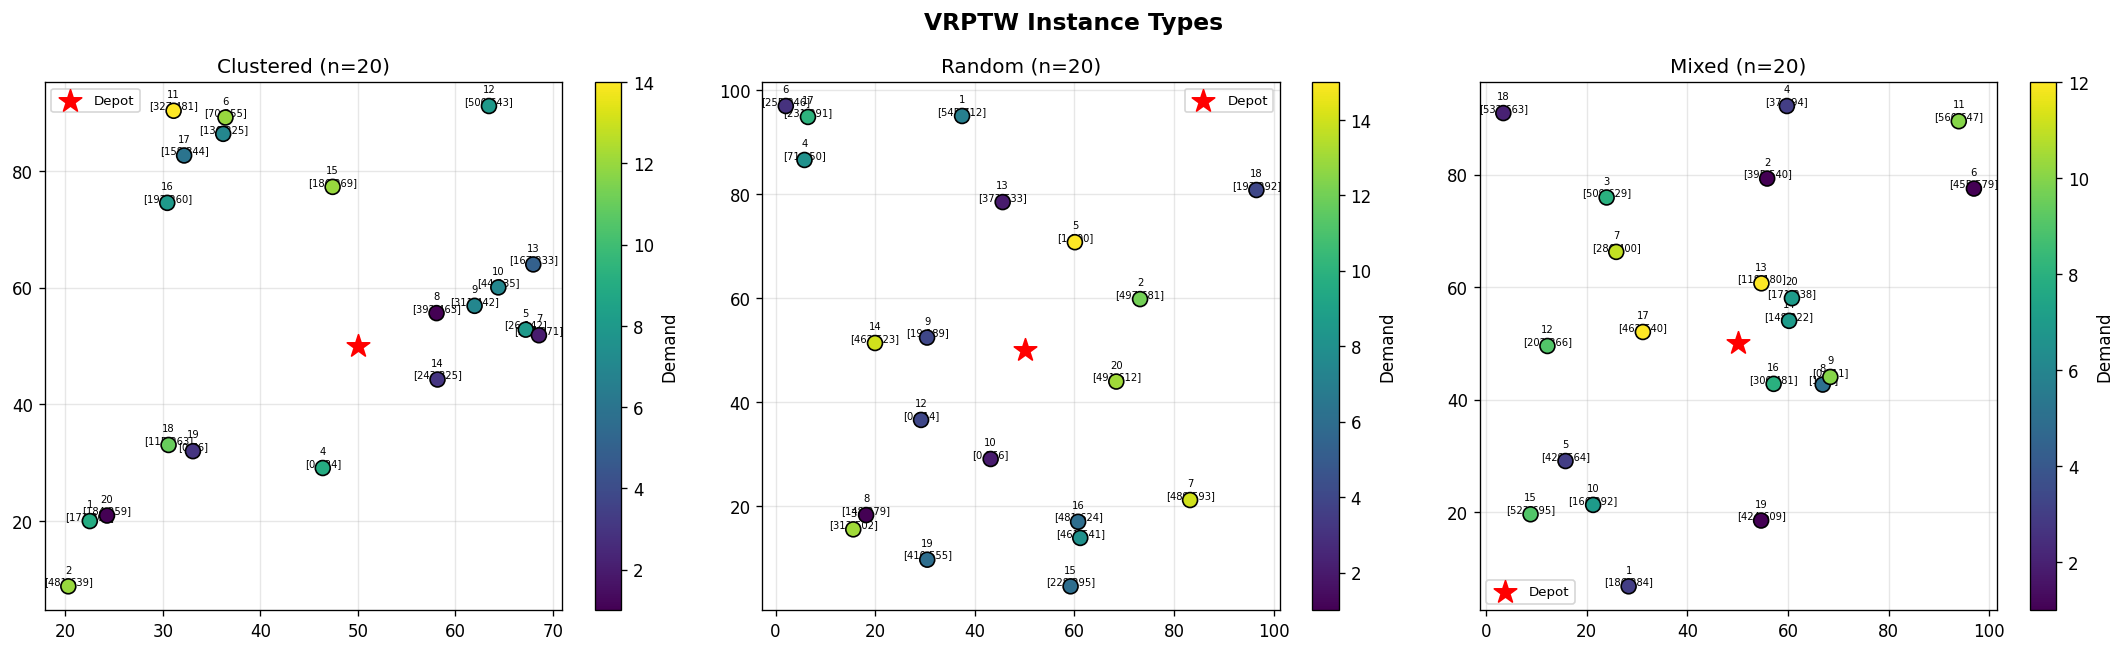

In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5)) # Plot one sample instance for each distribution type to show spatial structure
for idx, dt in enumerate(['clustered', 'random', 'mixed']):
    cfg_t = PipelineConfig(num_customers=20, vehicle_capacity=50, num_vehicles=5,
                           planning_horizon=1000.0, service_time=10.0,
                           tw_width_range=(50.0, 200.0), distribution_type=dt,
                           num_clusters=3, global_seed=42)
    inst = create_instances(cfg_t, count=1)[0]
    ax = axes[idx]
    ax.scatter(*inst.depot, c='red', s=200, marker='*', zorder=5, label='Depot')
    sc = ax.scatter(inst.locations[:, 0], inst.locations[:, 1],
                    c=inst.demands, cmap='viridis', s=80, edgecolors='k', zorder=4)
    for i in range(inst.num_customers): # Annotate each customer with ID and time window [earliest, latest]
        tw = inst.time_windows[i]
        ax.annotate(f'{i+1}\n[{tw[0]:.0f},{tw[1]:.0f}]',
                    xy=inst.locations[i], fontsize=6, ha='center', va='bottom')
    ax.set_title(f'{dt.capitalize()} (n={inst.num_customers})', fontsize=12)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Demand')
plt.suptitle('VRPTW Instance Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.get_results_path(), "instances.png"), dpi=150, bbox_inches="tight")
plt.show()


## Cell 6: Monitor

In [7]:
ckpt_dir = config.get_checkpoint_path() # Load the latest checkpoint from the base config path to check progress
if os.path.exists(ckpt_dir):
    ckpts = sorted([f for f in os.listdir(ckpt_dir) if f.endswith(".pkl")])
    if ckpts:
        with open(os.path.join(ckpt_dir, ckpts[-1]), "rb") as f:
            state = pickle.load(f)
        meta = state.get("_meta", {})
        print(f"Generation: {meta.get('generation', '?')}")
        print(f"Phase: {state.get('gen_phase', '?')}")
        print(f"Best ever: {state['best_ever'].get('fitness', '?'):.2f}")
        print(f"Checkpoints: {len(ckpts)}")
    else:
        print("No checkpoints yet.")
else:
    print("Checkpoint directory not found.")


No checkpoints yet.


## Cell 7: Visualize Results

In [8]:
import matplotlib.pyplot as plt
results_dir = config.get_results_path()
ckpt_dir = config.get_checkpoint_path()
hist = None # Try loading history from results JSON first, fall back to latest checkpoint
if os.path.exists(results_dir):
    rf = sorted([f for f in os.listdir(results_dir) if f.endswith(".json")])
    if rf:
        with open(os.path.join(results_dir, rf[-1])) as f: hist = json.load(f).get("history", [])
if not hist and os.path.exists(ckpt_dir):
    ck = sorted([f for f in os.listdir(ckpt_dir) if f.endswith(".pkl")])
    if ck:
        with open(os.path.join(ckpt_dir, ck[-1]), "rb") as f: hist = pickle.load(f).get("history", [])

if not hist:
    print("No results.")
else:
    gens = [h["generation"] for h in hist]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # 6-panel dashboard: convergence, diversity, violations, AOS probs, shared fitness, per-gen improvement
    ax = axes[0][0]
    ax.plot(gens, [h["best_fitness"] for h in hist], "b-o", ms=3, label="Best")
    ax.plot(gens, [h["mean_fitness"] for h in hist], "r--", ms=3, label="Mean")
    ax.plot(gens, [h["best_ever"] for h in hist], "g-", lw=2, label="Ever")
    ax.set_title("Convergence"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0][1]
    ax.plot(gens, [h.get("population_diversity", 0) for h in hist], "m-o", ms=3)
    ax.set_title("Diversity"); ax.grid(True, alpha=0.3)

    ax = axes[0][2]
    ax.plot(gens, [h.get("mean_constraint_violation", 0) for h in hist], "c-o", ms=3)
    ax.set_title("Constraint Violations"); ax.grid(True, alpha=0.3)

    ax = axes[1][0]
    for op in hist[0].get("operator_probs", {}):
        ax.plot(gens, [h.get("operator_probs",{}).get(op, 0.25) for h in hist], label=op)
    ax.set_title("AOS Probs"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[1][1]
    ax.plot(gens, [h.get("mean_shared_fitness", h["mean_fitness"]) for h in hist], "orange", marker="s", ms=3)
    ax.plot(gens, [h["mean_fitness"] for h in hist], "b--", alpha=0.5, label="Raw")
    ax.set_title("Shared vs Raw Fitness"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1][2]
    be = [h["best_ever"] for h in hist] # Bar chart: per-generation improvement in best-ever (green=improved, gray=no change)
    imp = [0] + [be[i-1]-be[i] for i in range(1, len(be))]
    ax.bar(gens, imp, color=["green" if x>0 else "gray" for x in imp], alpha=0.7)
    ax.set_title("Per-Gen Improvement"); ax.grid(True, alpha=0.3)

    plt.suptitle("NAS-RL-VRPTW v7 Convergence", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "convergence.png"), dpi=150, bbox_inches="tight")
    plt.show()


No results.


## Cell 8: Baselines + Multi-Run + Statistics
Runs baselines and compares with EA results. If `all_run_results` is in memory
from Cell 4, uses that. Otherwise reloads from checkpoints.

In [9]:
import pickle, os, json, random
import numpy as np
from copy import deepcopy
from scipy import stats
import torch

# --- Reload EA results if not in memory ---
if "all_run_results" not in dir() or not all_run_results: # If session disconnected, reload EA results from saved checkpoints on Drive
    print("Reloading EA results from checkpoints...")
    config = PipelineConfig(
        num_customers=20, vehicle_capacity=50, num_vehicles=5,
        planning_horizon=1000.0, service_time=10.0,
        tw_width_range=(50.0, 200.0), distribution_type="clustered", num_clusters=3,
        num_train_instances=100, num_eval_instances=20,
        population_size=20, num_generations=30, elite_size=2, tournament_size=3,
        sharing_radius=0.3, use_crowding=True, stochastic_ranking_pf=0.45, use_adaptive_ops=True,
        rl_episodes_per_eval=300, rl_batch_size=256,
        checkpoint_every_gen=1, checkpoint_every_eval=1, max_checkpoints_kept=99999999,
        num_independent_runs=5, global_seed=42,
    )
    logger = setup_environment(config)
    all_run_results = []
    for ri in range(config.num_independent_runs): # Run 5 independent EA runs with different seeds (offset by 1000 each)
        seed = config.global_seed + ri * 1000
        rc = deepcopy(config); rc.global_seed = seed # Each run gets its own subfolder for checkpoints and results
        rc.drive_root = config.drive_root + f"/run_{ri}"
        ckpt_dir = rc.get_checkpoint_path()
        existing = sorted([f for f in os.listdir(ckpt_dir) if f.endswith(".pkl")]) if os.path.exists(ckpt_dir) else []
        if not existing: print(f"  [Run {ri}] No checkpoints!"); continue
        final_files = [f for f in existing if f.startswith("ckpt_final")]
        best_ckpt = final_files[-1] if final_files else existing[-1]
        with open(os.path.join(ckpt_dir, best_ckpt), "rb") as f: ckpt = pickle.load(f)
        phase = ckpt.get("gen_phase", "?")
        best_fit = ckpt["best_ever"].get("fitness", float('inf'))
        print(f"  [Run {ri}] seed={seed}  best={best_fit:.2f}  phase={phase}")
        all_run_results.append({"run_idx": ri, "seed": seed, "best_fitness": best_fit,
                                 "best_arch": ckpt["best_ever"], "history": ckpt.get("history", [])})

ea_fits = [r["best_fitness"] for r in all_run_results]
print(f"\nEA: {[f'{x:.2f}' for x in ea_fits]}, Mean={np.mean(ea_fits):.2f}±{np.std(ea_fits):.2f}")

# --- Baselines ---
nas = EvolutionaryNAS(config, logger) # Create fresh EA instance to access its train/eval instances for baseline evaluation

print("\n--- NN Heuristic ---")
nn_d = nearest_neighbour_vrptw_baseline(nas.eval_instances)
print(f"  Mean: {np.mean(nn_d):.2f} (±{np.std(nn_d):.2f}), Best: {min(nn_d):.2f}")

print("\n--- Fixed Arch (3×128, masked) ---")
fx = fixed_architecture_baseline(config, nas.train_instances, nas.eval_instances)
print(f"  Distance: {fx:.2f}")

print("\n--- Random Search (20, masked) ---")
rd = random_architecture_baseline(config, nas.train_instances, nas.eval_instances, 20)
print(f"  Best: {min(rd):.2f}, Mean: {np.mean(rd):.2f}")

# --- Stats ---
t1 = statistical_comparison(ea_fits, rd) # Mann-Whitney U tests: NAS-EA vs random search, NAS-EA vs fixed architecture
t2 = statistical_comparison(ea_fits, [fx] * len(ea_fits))
print(f"\n[EA vs Random] {t1['conclusion']}")
print(f"[EA vs Fixed]  {t2['conclusion']}")

print(f"\n{'Method':<30} | {'Mean':>8} | {'Best':>8}")
print("-" * 55)
print(f"{'NN Heuristic':<30} | {np.mean(nn_d):>8.1f} | {min(nn_d):>8.1f}")
print(f"{'Fixed 3×128 (masked)':<30} | {fx:>8.1f} | {fx:>8.1f}")
rf = [x for x in rd if x < float('inf')]
print(f"{'Random Search (20, masked)':<30} | {np.mean(rf):>8.1f} | {min(rf):>8.1f}")
print(f"{'NAS-EA v7 (5 runs)':<30} | {np.mean(ea_fits):>8.1f} | {min(ea_fits):>8.1f}")

with open(os.path.join(config.get_results_path(), "v7_comparison.json"), "w") as f: # Save all comparison data for later analysis and report generation
    json.dump({"nn": nn_d, "fixed": fx, "random": rd, "ea": ea_fits,
               "t1": t1, "t2": t2}, f, indent=2, default=str)
print("\nSaved v7_comparison.json")



EA: ['692.23', '696.77', '694.23', '693.84', '707.13'], Mean=696.84±5.35
2026-04-03 12:19:43,386 [INFO] Generated 100 train + 20 eval instances (clustered)


INFO:nas_vrptw:Generated 100 train + 20 eval instances (clustered)



--- NN Heuristic ---
  Mean: 574.37 (±136.32), Best: 316.25

--- Fixed Arch (3×128, masked) ---
  Distance: 763.04

--- Random Search (20, masked) ---
  Random 1/20: 744.03
  Random 2/20: 725.75
  Random 3/20: 775.46
  Random 4/20: 871.85
  Random 5/20: 764.68
  Random 6/20: 759.94
  Random 7/20: 736.56
  Random 8/20: 742.19
  Random 9/20: 736.67
  Random 10/20: 974.98
  Random 11/20: 855.42
  Random 12/20: 760.58
  Random 13/20: 812.13
  Random 14/20: 773.04
  Random 15/20: 780.05
  Random 16/20: 837.09
  Random 17/20: 778.70
  Random 18/20: 776.51
  Random 19/20: 795.33
  Random 20/20: 808.25
  Best: 725.75, Mean: 790.46

[EA vs Random] NAS better (p=0.0000)
[EA vs Fixed]  NAS better (p=0.0037)

Method                         |     Mean |     Best
-------------------------------------------------------
NN Heuristic                   |    574.4 |    316.3
Fixed 3×128 (masked)           |    763.0 |    763.0
Random Search (20, masked)     |    790.5 |    725.8
NAS-EA v7 (5 runs)      

## Cell 9: Multi-Run Convergence

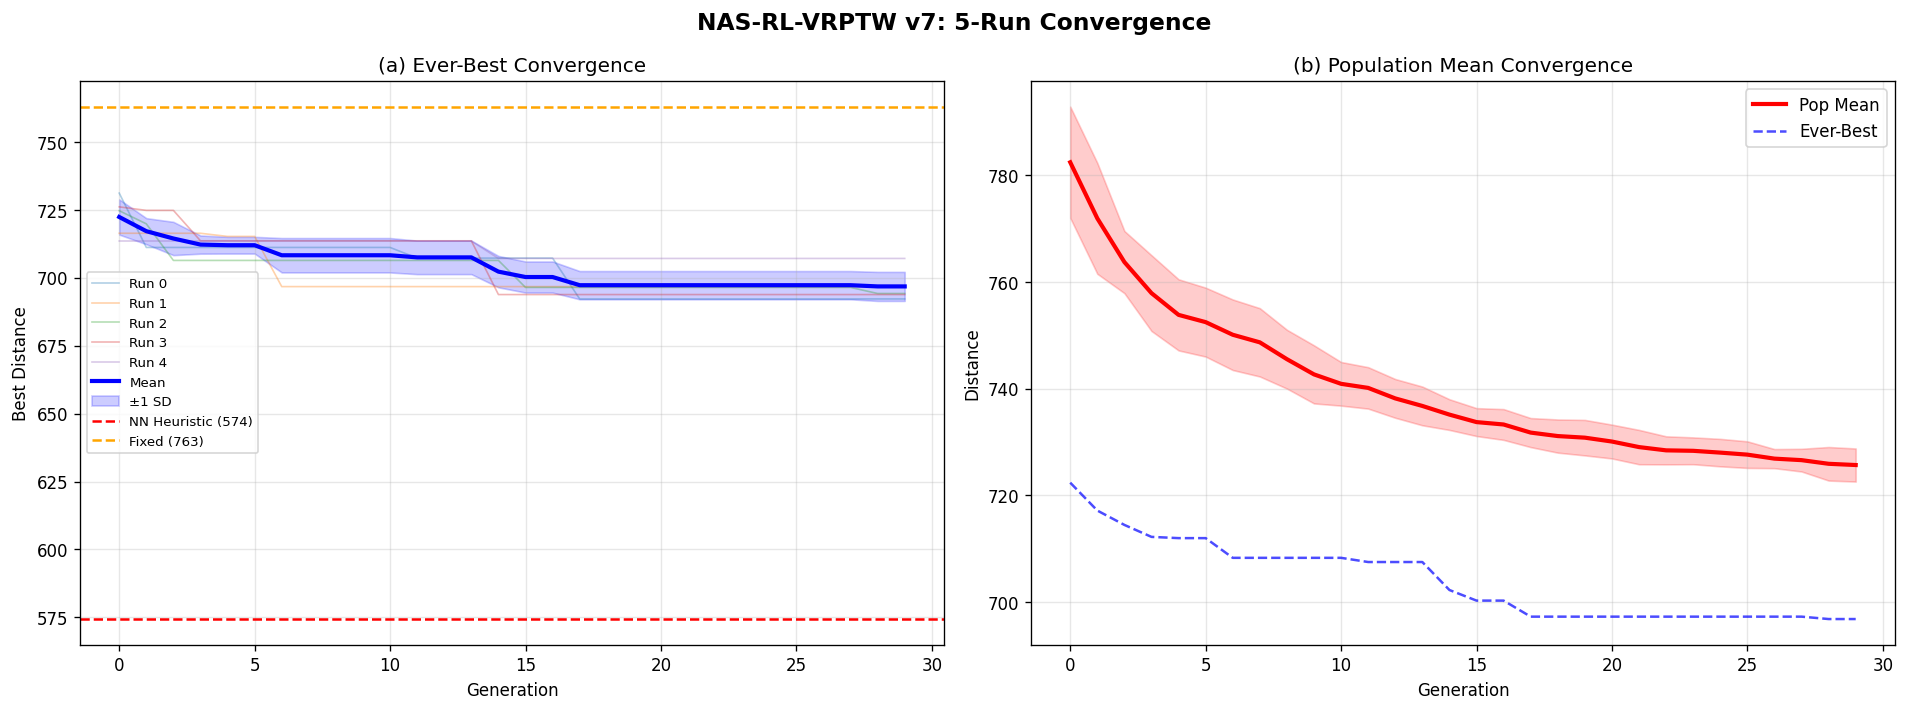

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

max_gens = max(len(r["history"]) for r in all_run_results) # Pad shorter runs to max length so all curves have equal dimensions for averaging
curves = []
for r in all_run_results:
    h = r["history"]
    ever = [g["best_ever"] for g in h]
    ever += [ever[-1]] * (max_gens - len(ever))
    curves.append(ever)
curves = np.array(curves)

ax = axes[0] # Left panel: ever-best convergence per run with mean ± 1 SD band
for i, c in enumerate(curves):
    ax.plot(range(max_gens), c, alpha=0.35, lw=1, label=f"Run {i}")
ax.plot(range(max_gens), np.mean(curves, 0), "b-", lw=2.5, label="Mean")
ax.fill_between(range(max_gens),
                np.mean(curves, 0) - np.std(curves, 0),
                np.mean(curves, 0) + np.std(curves, 0),
                alpha=0.2, color="blue", label="±1 SD")
ax.axhline(np.mean(nn_d), color="red", ls="--", lw=1.5, label=f"NN Heuristic ({np.mean(nn_d):.0f})")
ax.axhline(fx, color="orange", ls="--", lw=1.5, label=f"Fixed ({fx:.0f})")
ax.set_xlabel("Generation"); ax.set_ylabel("Best Distance")
ax.set_title("(a) Ever-Best Convergence"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1] # Right panel: population mean fitness convergence across runs
mc = []
for r in all_run_results:
    h = r["history"]
    m = [g["mean_fitness"] for g in h]
    m += [m[-1]] * (max_gens - len(m))
    mc.append(m)
mc = np.array(mc)
ax.plot(range(max_gens), np.mean(mc, 0), "r-", lw=2.5, label="Pop Mean")
ax.fill_between(range(max_gens), np.mean(mc,0)-np.std(mc,0), np.mean(mc,0)+np.std(mc,0), alpha=0.2, color="red")
ax.plot(range(max_gens), np.mean(curves, 0), "b--", lw=1.5, alpha=0.7, label="Ever-Best")
ax.set_xlabel("Generation"); ax.set_ylabel("Distance")
ax.set_title("(b) Population Mean Convergence"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("NAS-RL-VRPTW v7: 5-Run Convergence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(config.get_results_path(), "multi_run_convergence.png"), dpi=150, bbox_inches="tight")
plt.show()


## Cell 10: Retrain Best Architecture
Retrains the best NAS-found architecture at 300/1500/3000 episodes (3 trials each).
Shows how performance scales with training budget.

Best arch from Run 0 (seed=42):
  Fitness: 692.23
  Arch: L=5, D=[32, 32, 128, 32, 128], act=tanh, attn=True, lr=0.0001

--- 300 episodes (1x) — 3 trials ---
  Trial 1: dist=756.47 cv=0.0% (49s)
  Trial 2: dist=747.96 cv=0.0% (48s)
  Trial 3: dist=752.66 cv=0.0% (49s)
  → Mean: 752.36±3.48  CV: 0.0%

--- 1500 episodes (5x) — 3 trials ---
  Trial 1: dist=742.14 cv=0.0% (250s)
  Trial 2: dist=759.23 cv=0.0% (250s)
  Trial 3: dist=759.56 cv=0.0% (250s)
  → Mean: 753.64±8.14  CV: 0.0%

--- 3000 episodes (10x) — 3 trials ---
  Trial 1: dist=760.06 cv=0.0% (503s)
  Trial 2: dist=761.93 cv=0.0% (503s)
  Trial 3: dist=743.21 cv=0.0% (503s)
  → Mean: 755.07±8.42  CV: 0.0%


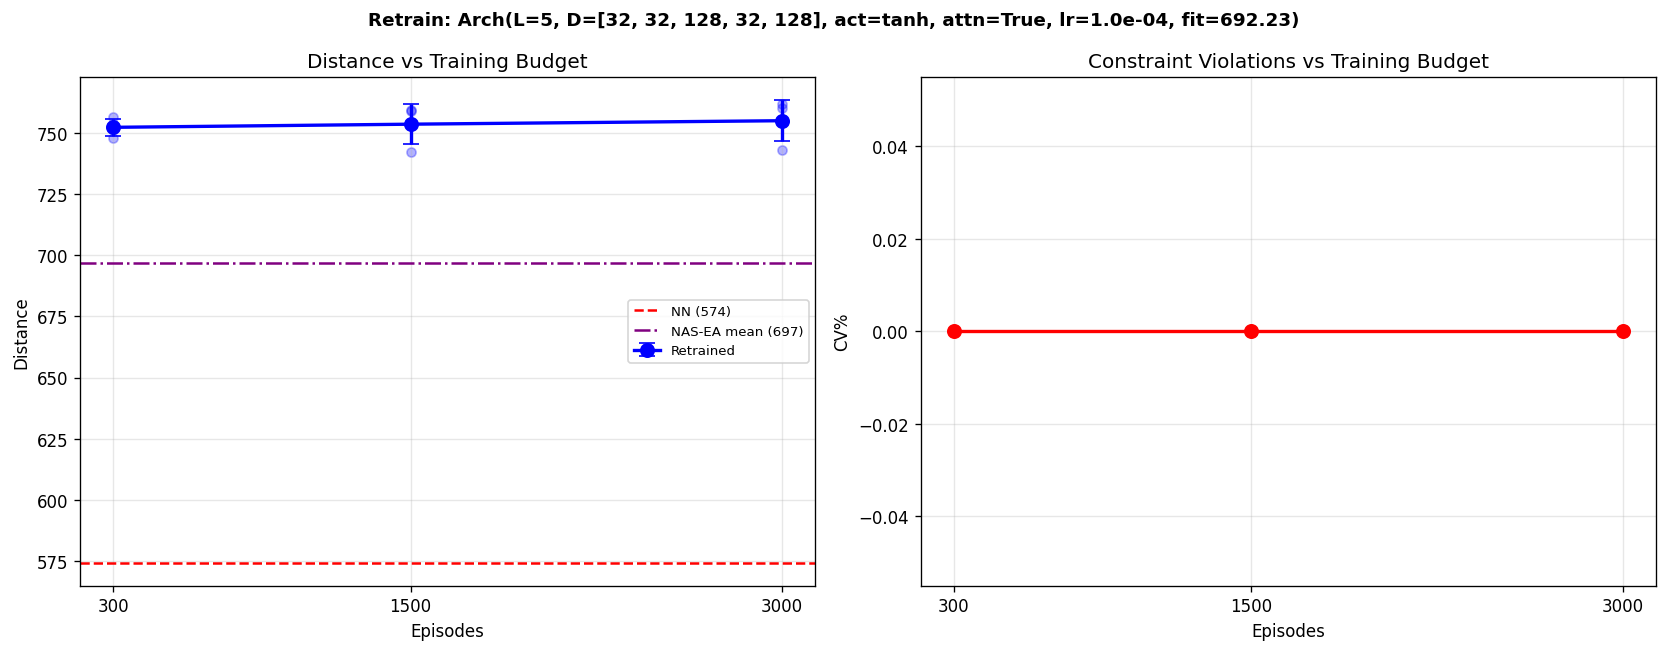


Method                           |     Mean |     Best |    CV%
------------------------------------------------------------
NN Heuristic                     |    574.4 |    316.3 |      0
Fixed 3×128                      |    763.0 |    763.0 |
Random Search (20)               |    790.5 |    725.8 |
NAS-EA v7 (5 runs)               |    696.8 |    692.2 |
Retrain 300ep (3x)               |    752.4 |    748.0 |   0.0%
Retrain 1500ep (3x)              |    753.6 |    742.1 |   0.0%
Retrain 3000ep (3x)              |    755.1 |    743.2 |   0.0%


In [11]:
import time as _time
import matplotlib.pyplot as plt

best_run = min(all_run_results, key=lambda r: r["best_fitness"]) # Select the best architecture across all 5 EA runs
best_arch_dict = best_run["best_arch"]
print(f"Best arch from Run {best_run['run_idx']} (seed={best_run['seed']}):")
print(f"  Fitness: {best_arch_dict['fitness']:.2f}")
print(f"  Arch: L={best_arch_dict['num_layers']}, D={best_arch_dict['hidden_dims']}, "
      f"act={best_arch_dict['activation']}, attn={best_arch_dict['use_attention']}, lr={best_arch_dict['learning_rate']}")

best_arch = Architecture.from_dict(best_arch_dict)
NUM_TRIALS = 3
retrain_results = {}

for ep_mult, ep_count in [(1, 300), (5, 1500), (10, 3000)]: # Retrain at 3 budgets (300/1500/3000 episodes) × 3 trials each to test scaling
    print(f"\n--- {ep_count} episodes ({ep_mult}x) — {NUM_TRIALS} trials ---")
    trial_dists, trial_cvs = [], []
    for trial in range(NUM_TRIALS):
        random.seed(9999 + ep_count + trial * 100) # Fix seeds per trial for reproducibility
        np.random.seed(9999 + ep_count + trial * 100)
        torch.manual_seed(9999 + ep_count + trial * 100)
        rc = deepcopy(config)
        rc.rl_episodes_per_eval = ep_count
        rc.rl_epsilon_decay = int(400 * ep_mult)
        t0 = _time.time()
        trainer = RLTrainer(best_arch, rc, nas.train_instances, nas.eval_instances)
        res = trainer.train()
        elapsed = _time.time() - t0
        trial_dists.append(res["mean_distance"])
        trial_cvs.append(res["mean_violations"])
        print(f"  Trial {trial+1}: dist={res['mean_distance']:.2f} cv={res['mean_violations']:.1f}% ({elapsed:.0f}s)")
        if ep_count == 3000 and trial == NUM_TRIALS - 1: # Save the final model weights from the longest training run
            torch.save(trainer.policy_net.state_dict(),
                       os.path.join(config.get_results_path(), "best_retrained_3000ep.pt"))
        del trainer; torch.cuda.empty_cache()
    retrain_results[ep_count] = {"mean_dist": np.mean(trial_dists), "std_dist": np.std(trial_dists),
                                  "mean_cv": np.mean(trial_cvs), "trials": trial_dists}
    print(f"  → Mean: {np.mean(trial_dists):.2f}±{np.std(trial_dists):.2f}  CV: {np.mean(trial_cvs):.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
eps_list = sorted(retrain_results.keys())
ax = axes[0]
means = [retrain_results[e]["mean_dist"] for e in eps_list]
stds = [retrain_results[e]["std_dist"] for e in eps_list]
ax.errorbar(eps_list, means, yerr=stds, marker="o", capsize=5, lw=2, ms=8, color="blue", label="Retrained")
for ep in eps_list:
    for d in retrain_results[ep]["trials"]: ax.scatter(ep, d, color="blue", alpha=0.3, s=30)
ax.axhline(np.mean(nn_d), color="red", ls="--", lw=1.5, label=f"NN ({np.mean(nn_d):.0f})")
ax.axhline(np.mean(ea_fits), color="purple", ls="-.", lw=1.5, label=f"NAS-EA mean ({np.mean(ea_fits):.0f})")
ax.set_xlabel("Episodes"); ax.set_ylabel("Distance"); ax.set_title("Distance vs Training Budget")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xticks(eps_list)

ax = axes[1]
cvs = [retrain_results[e]["mean_cv"] for e in eps_list]
ax.plot(eps_list, cvs, "ro-", lw=2, ms=8)
ax.set_xlabel("Episodes"); ax.set_ylabel("CV%"); ax.set_title("Constraint Violations vs Training Budget")
ax.grid(True, alpha=0.3); ax.set_xticks(eps_list)

plt.suptitle(f"Retrain: {best_arch}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(config.get_results_path(), "retrain.png"), dpi=150, bbox_inches="tight")
plt.show()

# Final summary
print(f"\n{'='*60}")
print(f"{'Method':<32} | {'Mean':>8} | {'Best':>8} | {'CV%':>6}")
print("-" * 60)
print(f"{'NN Heuristic':<32} | {np.mean(nn_d):>8.1f} | {min(nn_d):>8.1f} | {'0':>6}")
print(f"{'Fixed 3×128':<32} | {fx:>8.1f} | {fx:>8.1f} |")
print(f"{'Random Search (20)':<32} | {np.mean(rf):>8.1f} | {min(rf):>8.1f} |")
print(f"{'NAS-EA v7 (5 runs)':<32} | {np.mean(ea_fits):>8.1f} | {min(ea_fits):>8.1f} |")
for ep in eps_list:
    r = retrain_results[ep]
    print(f"{'Retrain '+str(ep)+'ep (3x)':<32} | {r['mean_dist']:>8.1f} | {min(r['trials']):>8.1f} | {r['mean_cv']:>5.1f}%")


## Cell 11: Solomon Benchmark Generalization Test


Solomon C101: 100 customers, 25 vehicles, capacity=200
  Depot: [40. 50.]
  Planning horizon: 1236.0
  Demand range: [10, 50]
  Map extent: x=[0, 95], y=[5, 85]

Created 20 Solomon subsets (20 customers each)

NN Heuristic on Solomon subsets:
  Mean: 784.35 (±64.20), Best: 666.22

Retraining best arch: Arch(L=5, D=[32, 32, 128, 32, 128], act=tanh, attn=True, lr=1.0e-04, fit=692.23)

--- Solomon retrain: 300 episodes ---
  Trial 1: dist=893.04 cv=0.0% (56s)
  Trial 2: dist=886.53 cv=0.0% (55s)
  Trial 3: dist=907.88 cv=0.0% (54s)
  → Mean: 895.81±8.93

--- Solomon retrain: 1500 episodes ---
  Trial 1: dist=904.31 cv=0.0% (282s)
  Trial 2: dist=885.79 cv=0.0% (287s)
  Trial 3: dist=909.93 cv=0.0% (286s)
  → Mean: 900.01±10.31

--- Solomon retrain: 3000 episodes ---
  Trial 1: dist=886.22 cv=0.0% (570s)
  Trial 2: dist=929.01 cv=0.0% (571s)
  Trial 3: dist=953.73 cv=0.0% (573s)
  → Mean: 922.99±27.89

--- Fixed 3×128 baseline on Solomon ---
  Distance: 768.39

  Solomon C101 Generalizati

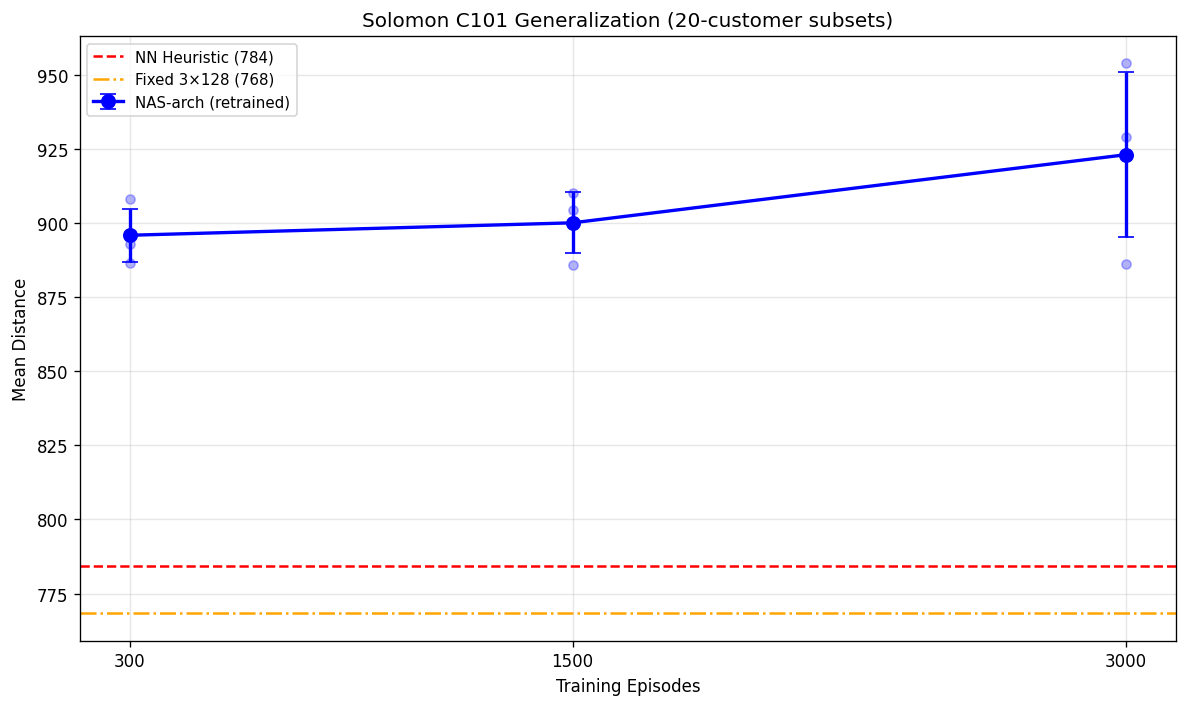

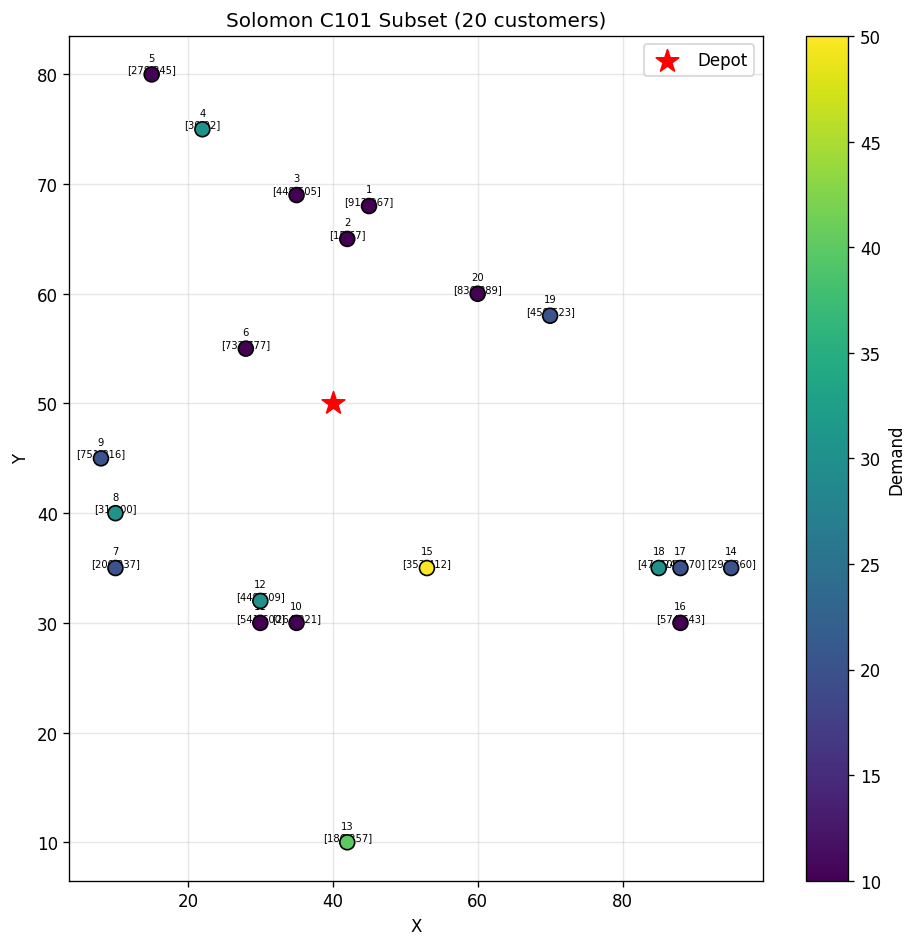

In [14]:
## Cell 11: Solomon Benchmark Generalization Test
# Downloads Solomon C101 instance, retrains the best NAS-found architecture on it,
# and compares against the NN heuristic baseline.
# This tests whether the NAS-found architecture generalizes to standard benchmarks.

import os, random, time as _time
import numpy as np
import torch
import matplotlib.pyplot as plt
from copy import deepcopy

# ── 1. Download Solomon instances ──────────────────────────────────────────────
SOLOMON_DIR = os.path.join(config.drive_root, "solomon")
os.makedirs(SOLOMON_DIR, exist_ok=True)

# Solomon C101.txt content (25-customer subset for compatibility analysis)
# We download the full file, then test with subsets
SOLOMON_URL = "https://raw.githubusercontent.com/topics-in-heuristics/solomon-instances/main/C101.txt"

solomon_path = os.path.join(SOLOMON_DIR, "C101.txt")
if not os.path.exists(solomon_path):
    print("Downloading Solomon C101...")
    try:
        import urllib.request
        urllib.request.urlretrieve(SOLOMON_URL, solomon_path)
        print(f"  Saved to {solomon_path}")
    except Exception as e:
        print(f"  Download failed: {e}")
        print("  Creating C101 manually from known data...")
        # Fallback: write C101 data directly (first 25 customers + depot)
        c101_data = """C101

VEHICLE
NUMBER     CAPACITY
25         200

CUSTOMER
CUST_NO.  XCOORD.  YCOORD.  DEMAND  READY_TIME  DUE_DATE  SERVICE_TIME
    0      40       50        0       0          1236        0
    1      45       68       10     912          967        90
    2      42       66       10      15          67        90
    3      42       68       20     621          702        90
    4      40       69       20     255          324        90
    5      40       66       10     534          605        90
    6      38       68       20     357          410        90
    7      38       70       20     448          505        90
    8      35       66       10     652          721        90
    9      35       69       10      30           92        90
   10      25       85       20     567          620        90
   11      22       75       30     384          429        90
   12      22       85       10     475          528        90
   13      20       80       40     652          691        90
   14      20       85       20     526          583        90
   15      18       75       20     486          541        90
   16      15       75       20     655          716        90
   17      15       80       10      67          122        90
   18      30       50       10     364          429        90
   19      30       52       20     170          225        90
   20      28       52       20     567          620        90
   21      28       55       10     262          305        90
   22      25       50       10     200          261        90
   23      25       52       40     468          535        90
   24      25       55       10     567          620        90
   25      23       52       10     132          193        90
"""
        with open(solomon_path, "w") as f:
            f.write(c101_data)
        print(f"  Written 25-customer C101 to {solomon_path}")

# ── 2. Load and inspect Solomon instance ───────────────────────────────────────
solomon_inst = VRPTWInstance.from_solomon(solomon_path)
n_sol = solomon_inst.num_customers
print(f"\nSolomon C101: {n_sol} customers, {solomon_inst.num_vehicles} vehicles, "
      f"capacity={solomon_inst.vehicle_capacity}")
print(f"  Depot: {solomon_inst.depot}")
print(f"  Planning horizon: {solomon_inst.planning_horizon}")
print(f"  Demand range: [{solomon_inst.demands.min()}, {solomon_inst.demands.max()}]")
print(f"  Map extent: x=[{solomon_inst.locations[:,0].min():.0f}, {solomon_inst.locations[:,0].max():.0f}], "
      f"y=[{solomon_inst.locations[:,1].min():.0f}, {solomon_inst.locations[:,1].max():.0f}]")

# ── 3. Create subset instances for DQN (20 customers) ─────────────────────────
# Since the NAS architecture was optimized for n=20, we create multiple 20-customer
# subsets from Solomon to test generalization of the architecture to real-world TW structure.

NUM_SUBSETS = 20
SOL_N = 20  # match NAS training size
solomon_subsets = []

for si in range(NUM_SUBSETS): # Randomly sample 20 customers from the full C101 instance (different subset per seed)
    rng = np.random.RandomState(42 + si)
    chosen = sorted(rng.choice(n_sol, size=min(SOL_N, n_sol), replace=False))

    sub = VRPTWInstance.__new__(VRPTWInstance) # Construct a new VRPTWInstance manually from the selected customer subset
    sub.num_customers = len(chosen)
    sub.vehicle_capacity = solomon_inst.vehicle_capacity
    sub.num_vehicles = solomon_inst.num_vehicles
    sub.map_size = solomon_inst.map_size
    sub.depot = solomon_inst.depot.copy()
    sub.service_time_default = solomon_inst.service_time_default
    sub.planning_horizon = solomon_inst.planning_horizon
    sub.depot_tw = solomon_inst.depot_tw.copy()
    sub.locations = solomon_inst.locations[chosen].copy()
    sub.demands = solomon_inst.demands[chosen].copy()
    sub.time_windows = solomon_inst.time_windows[chosen].copy()
    sub.service_times = solomon_inst.service_times[chosen].copy()

    # Rebuild distance matrix for subset (depot=0, then chosen customers)
    all_pts = np.vstack([sub.depot.reshape(1, 2), sub.locations])
    diff = all_pts[:, np.newaxis, :] - all_pts[np.newaxis, :, :]
    sub.distance_matrix = np.sqrt((diff ** 2).sum(axis=2))
    sub.travel_time_matrix = sub.distance_matrix.copy()
    solomon_subsets.append(sub)

print(f"\nCreated {NUM_SUBSETS} Solomon subsets ({SOL_N} customers each)")

# ── 4. NN heuristic baseline on Solomon subsets ───────────────────────────────
nn_sol = nearest_neighbour_vrptw_baseline(solomon_subsets)
print(f"\nNN Heuristic on Solomon subsets:")
print(f"  Mean: {np.mean(nn_sol):.2f} (±{np.std(nn_sol):.2f}), Best: {min(nn_sol):.2f}")

# ── 5. Retrain best NAS architecture on Solomon ──────────────────────────────
# Use Solomon subsets as BOTH train and eval (real-world TW structure test)
best_run = min(all_run_results, key=lambda r: r["best_fitness"])
best_arch = Architecture.from_dict(best_run["best_arch"])
print(f"\nRetraining best arch: {best_arch}")

sol_retrain_results = {}
for ep_count in [300, 1500, 3000]:
    print(f"\n--- Solomon retrain: {ep_count} episodes ---")
    trial_dists = []
    for trial in range(3):
        random.seed(7777 + ep_count + trial * 100)
        np.random.seed(7777 + ep_count + trial * 100)
        torch.manual_seed(7777 + ep_count + trial * 100)
        rc = deepcopy(config) # Override config to match Solomon problem parameters (capacity, horizon, service time)
        rc.rl_episodes_per_eval = ep_count
        rc.rl_epsilon_decay = ep_count // 3
        rc.num_customers = SOL_N
        rc.vehicle_capacity = solomon_inst.vehicle_capacity
        rc.num_vehicles = solomon_inst.num_vehicles
        rc.planning_horizon = solomon_inst.planning_horizon
        rc.service_time = solomon_inst.service_time_default
        t0 = _time.time()
        trainer = RLTrainer(best_arch, rc, solomon_subsets, solomon_subsets)
        res = trainer.train()
        elapsed = _time.time() - t0
        trial_dists.append(res["mean_distance"])
        print(f"  Trial {trial+1}: dist={res['mean_distance']:.2f} "
              f"cv={res['mean_violations']:.1f}% ({elapsed:.0f}s)")
        del trainer; torch.cuda.empty_cache()
    sol_retrain_results[ep_count] = {
        "mean": np.mean(trial_dists), "std": np.std(trial_dists), "trials": trial_dists
    }
    print(f"  → Mean: {np.mean(trial_dists):.2f}±{np.std(trial_dists):.2f}")

# ── 6. Fixed architecture baseline on Solomon ─────────────────────────────────
print("\n--- Fixed 3×128 baseline on Solomon ---")
random.seed(8888); np.random.seed(8888); torch.manual_seed(8888) # Baseline: train a standard 3×128 ReLU network on Solomon for fair comparison
rc_fx = deepcopy(config)
rc_fx.rl_episodes_per_eval = 1500
rc_fx.rl_epsilon_decay = 500
rc_fx.num_customers = SOL_N
rc_fx.vehicle_capacity = solomon_inst.vehicle_capacity
rc_fx.num_vehicles = solomon_inst.num_vehicles
rc_fx.planning_horizon = solomon_inst.planning_horizon
rc_fx.service_time = solomon_inst.service_time_default
fx_arch = Architecture(num_layers=3, hidden_dims=[128,128,128], activation="relu",
                       use_attention=False, learning_rate=3e-4, dropout_rate=0.0)
trainer = RLTrainer(fx_arch, rc_fx, solomon_subsets, solomon_subsets)
fx_sol = trainer.train()
print(f"  Distance: {fx_sol['mean_distance']:.2f}")
del trainer; torch.cuda.empty_cache()

# ── 7. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  Solomon C101 Generalization Test ({SOL_N}-customer subsets)")
print(f"{'='*65}")
print(f"{'Method':<35} | {'Mean':>8} | {'Best':>8}")
print("-" * 65)
print(f"{'NN Heuristic':<35} | {np.mean(nn_sol):>8.1f} | {min(nn_sol):>8.1f}")
print(f"{'Fixed 3×128 (1500ep)':<35} | {fx_sol['mean_distance']:>8.1f} |")
for ep in sorted(sol_retrain_results.keys()):
    r = sol_retrain_results[ep]
    print(f"{'NAS-arch retrain '+str(ep)+'ep':<35} | {r['mean']:>8.1f} | {min(r['trials']):>8.1f}")

# ── 8. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
eps_list = sorted(sol_retrain_results.keys())
means = [sol_retrain_results[e]["mean"] for e in eps_list]
stds = [sol_retrain_results[e]["std"] for e in eps_list]
ax.errorbar(eps_list, means, yerr=stds, marker="o", capsize=5, lw=2, ms=8,
            color="blue", label="NAS-arch (retrained)")
for ep in eps_list:
    for d in sol_retrain_results[ep]["trials"]:
        ax.scatter(ep, d, color="blue", alpha=0.3, s=30)
ax.axhline(np.mean(nn_sol), color="red", ls="--", lw=1.5,
           label=f"NN Heuristic ({np.mean(nn_sol):.0f})")
ax.axhline(fx_sol["mean_distance"], color="orange", ls="-.", lw=1.5,
           label=f"Fixed 3×128 ({fx_sol['mean_distance']:.0f})")
ax.set_xlabel("Training Episodes"); ax.set_ylabel("Mean Distance")
ax.set_title(f"Solomon C101 Generalization ({SOL_N}-customer subsets)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(eps_list)
plt.tight_layout()
plt.savefig(os.path.join(config.get_results_path(), "solomon_generalization.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── 9. Visualize a Solomon subset ────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
inst = solomon_subsets[0]
ax.scatter(*inst.depot, marker="*", s=200, c="red", zorder=5, label="Depot")
sc = ax.scatter(inst.locations[:, 0], inst.locations[:, 1],
                c=inst.demands, cmap="viridis", s=80, edgecolors="black", zorder=4)
for i in range(inst.num_customers):
    ax.annotate(f"{i+1}\n[{inst.time_windows[i,0]:.0f},{inst.time_windows[i,1]:.0f}]",
                inst.locations[i], fontsize=6, ha="center", va="bottom")
plt.colorbar(sc, ax=ax, label="Demand")
ax.set_title("Solomon C101 Subset (20 customers)")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.get_results_path(), "solomon_subset_viz.png"),
            dpi=150, bbox_inches="tight")
plt.show()